# Gradient-Based Attribution vs PCI

> **Summary.** Compares PCI's responsibility scores against gradient / sensitivity-based attribution methods on a controlled synthetic model. Probes invariance to feature scale, sensitivity to priors, and the differential causal effect (DCE). Targets the paper's discussion of why gradient methods are not causally faithful even when their numbers look plausible.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from IPython.display import Image, display
from pyro.distributions import transforms

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ

import os
import pickle

sample_size = 10 if smoke_test else 3000
n_size = 5 if smoke_test else 500
num_search_samples = 10 if smoke_test else 5000

In [2]:
def add_line_end_label(ax, x, y, text, color="black"):
    ax.text(
        x,  # apply horizontal shift
        y,
        f"{text}",
        fontsize=14,
        ha="left",
        va="center",
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec=color,
            lw=1.2,
            alpha=0.85,
        ),
    )

## Overview

### Motivations

In a typical setting ATE is $\mathbb{E}(Y\vert do(X=1)) - \mathbb{E}(Y\vert do(X=0))$, i.e. $\mathbb{E}(Y_{X=1} - Y_{X=0})$. If the cause is categorical, one chooses levels of interest and estimates $\mathbb{E}(Y_{X=a} - Y_{X=b})$ for two categories $a, b$. One natural extension to a continuous cause is to take the limit of a shrinking contrast:

> If we want to generalize  $\mathbb{E}(Y_{X=1} - Y_{X=0})$ to the case where $X$ is continuous, we arrive at derivative calculus. For some baseline $do(X=x)$, imagine changing the intervention value $x$ by some small amount $\Delta$, i.e. $do(X=x+\Delta)$. Taking the difference between the two outcomes, we get $\mathbb{E}(Y_{X=x+\Delta} - Y_{X=x})$, then we can ask, what is the rate of change of $\mathbb{E}(Y_{X})$ as we make $\Delta$ infinitesimally smaller. (Ness, *Causal AI*, 2025, §7.4.3.)

This suggests using $\frac{d\,\mathbb{E}(Y_{X=x})}{dx}$, and, potentially, its conditional counterparts.


Generalizing to multiple inputs, let the intervention vector be
$\mathbf{X} = (X_1,\ldots,X_d)$ and denote the interventional mean function by
$
m(\mathbf{x}) = \mathbb{E}\bigl(Y_{\mathbf{X}=\mathbf{x}}\bigr).
$ For a small perturbation $\mathbf{x} \mapsto \mathbf{x} + \boldsymbol{\Delta}$,
the causal contrast
$
m(\mathbf{x} + \boldsymbol{\Delta}) - m(\mathbf{x})
$
captures the effect of jointly modifying several causal variables.

Taking limits yields the **causal gradient**
$ \nabla_{\mathbf{x}}\, m(\mathbf{x})
= \left(
\frac{\partial}{\partial x_1}\mathbb{E}(Y_{\mathbf{X}=\mathbf{x}}),
\;\ldots\;,
\frac{\partial}{\partial x_d}\mathbb{E}(Y_{\mathbf{X}=\mathbf{x}})
\right), $
where each partial derivative is the **differential causal effect** (DCE) of a single variable at the
intervention point $\mathbf{x}$.

This approach was taken by Butler, Feng and Djurić (*A Differential Measure of Strength of Causation*, IEEE Signal Processing Letters, vol. 29, 2022), who extended ATE to nonlinear functions and allowed for modulatory effects of covariates. They introduced DCE in the context of Gaussian Process regression (GPR), where the posterior expected mean can be written as $\sum_{n=1}^N k(x, x^{(n)}) \alpha_n$, with $x^{(n)}$ training inputs, $x$ a test point, and $\alpha_n$ the $n$-th entry of $(\mathbf{K} + \sigma^2 \mathbf{I})^{-1}y$. DCE then has the closed form $\frac{\partial \hat{F}}{\partial x_i} = \sum_{n=1}^{N} \frac{\partial k (x, x^{(n)})}{\partial x_i}\alpha_n$.

Our goal in this notebook is to build up some minimally interesting models that contrast DCE with PCI. The main differences we will illustrate:


1. DCE is restricted to relationships of the form $y := F(\mathbf{X}, \epsilon)$, with $F$ differentiable. PCI requires only that the causal model be sampleable; the choice of inference algorithm for the expanded model is up to the user. Throughout we use Monte Carlo, but other inference algorithms can be substituted.
2. The units of DCE are determined by the units of both $Y$ and $\mathbf{X}$, which makes DCE harder to compare across features. The choice of input units has little impact on the PCI score, because inputs are integrated out using the densities they receive in the necessity and sufficiency worlds.
3. The PCI score does depend on input values, but does not change as abruptly as DCE can. The change depends on where a given input sits relative to its necessity/sufficiency distribution. In our example this yields a notion that captures non-null responsibility even in flat regions of the response surface, without being extremely sensitive to very local changes.

### The model and exploration setup

We model an applicant's credit limit as a function of age and the time of day at which their application is evaluated. The model reflects the notion that credit limits increase sharply within a limited age range, and that applications reviewed in the morning or immediately after lunch are associated with slightly higher limits, potentially reflecting systematic variations in reviewer disposition throughout the day. Unconditioned inputs are assumed to come from probability distributions (taken to be normal for simplicity), and we wrap the deterministic component within a Bayesian model that incorporates these uncertainties.

We consider four settings along two axes. The first axis is whether time is measured in minutes or in hours. The deterministic models give qualitatively the same predictions modulo this scale transformation.

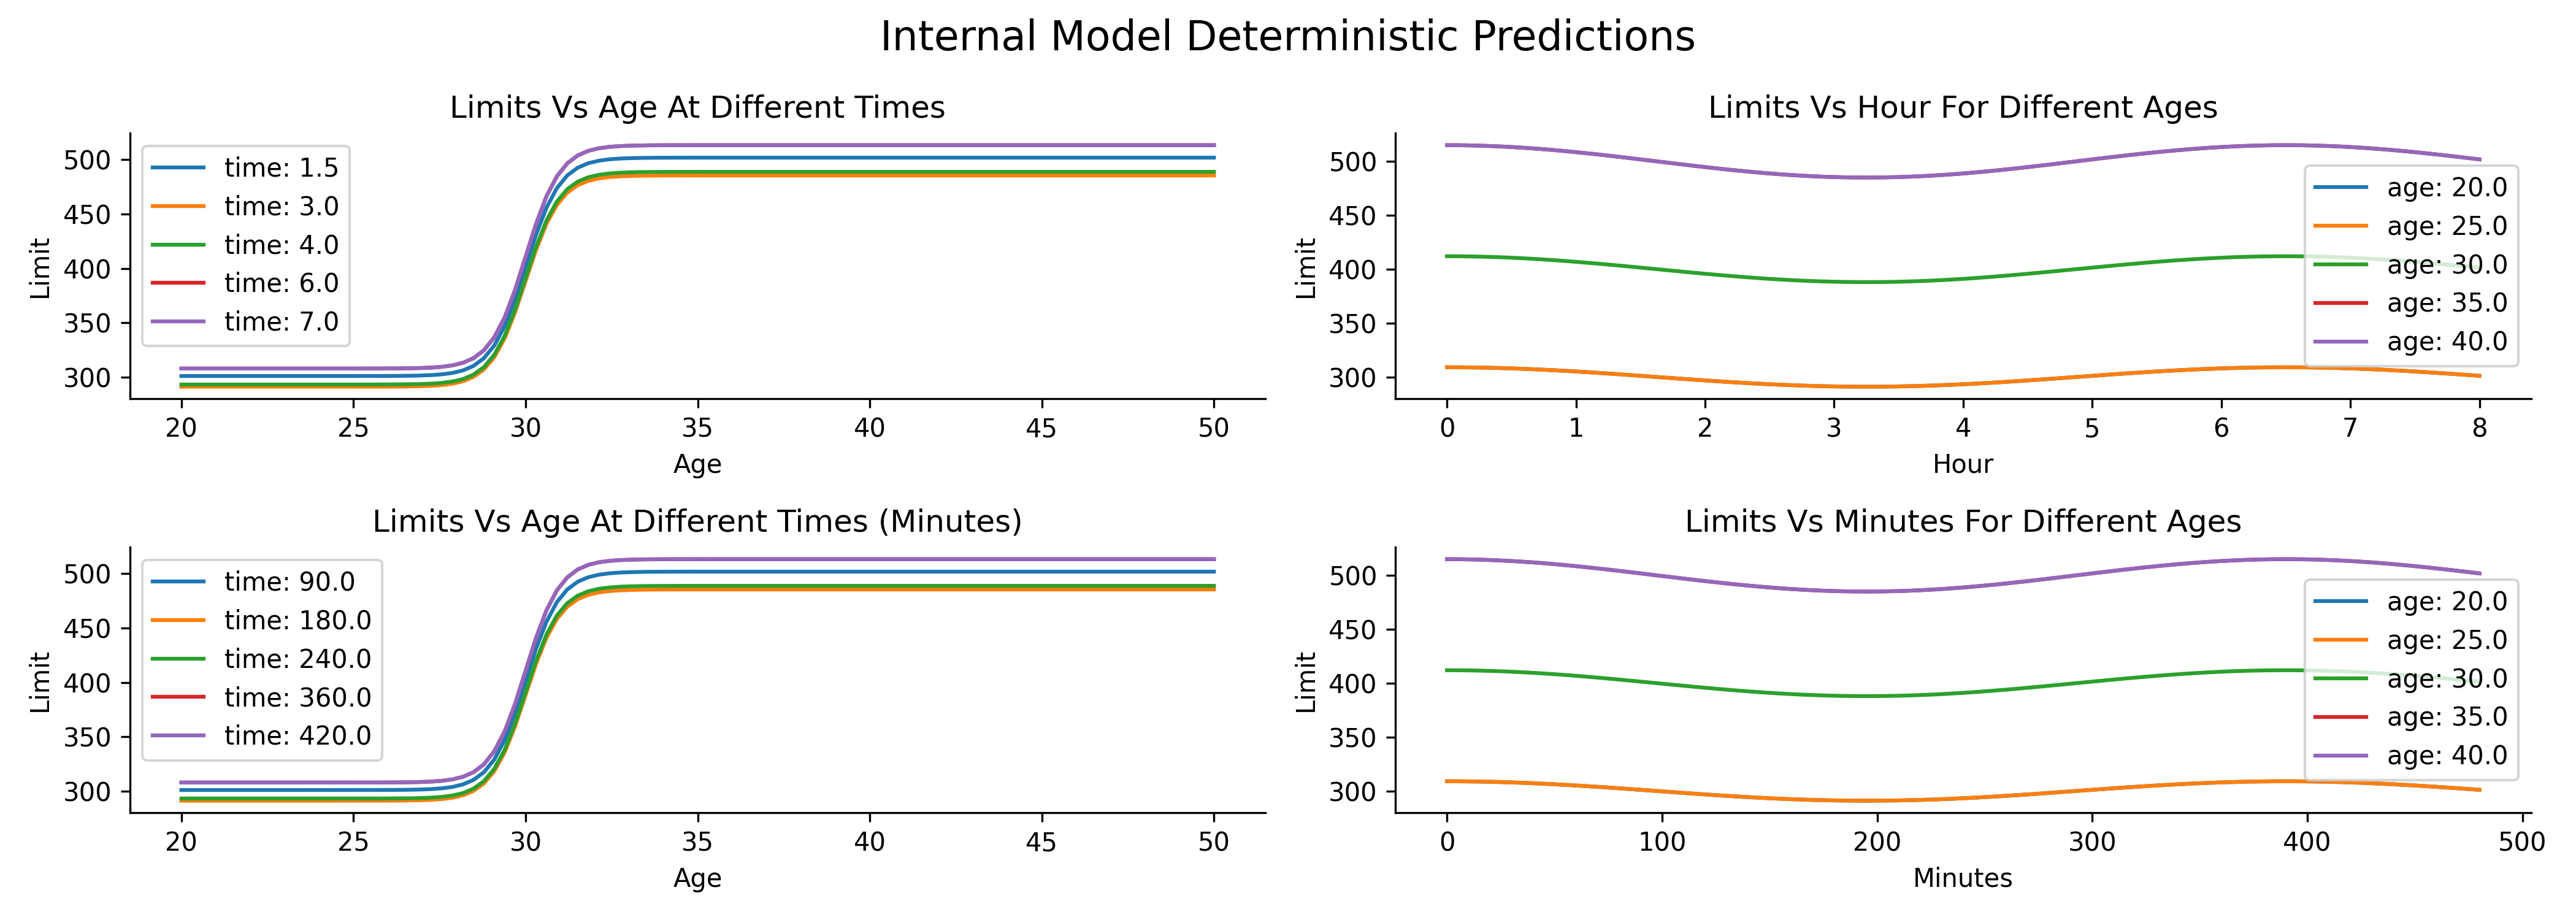

In [3]:
display(Image(filename="dce/internal_model_predictions.png"))

To compute PCI scores, we add a Bayesian layer. The second axis of difference between settings is the prior on age: we use two priors, which yield different push-forward distributions for the approved credit limit. Time of application is modeled by a single normal $\mathcal{N}(4,\,0.9)$ on the hour scale (correspondingly $\mathcal{N}(240,\,54)$ on the minute scale).

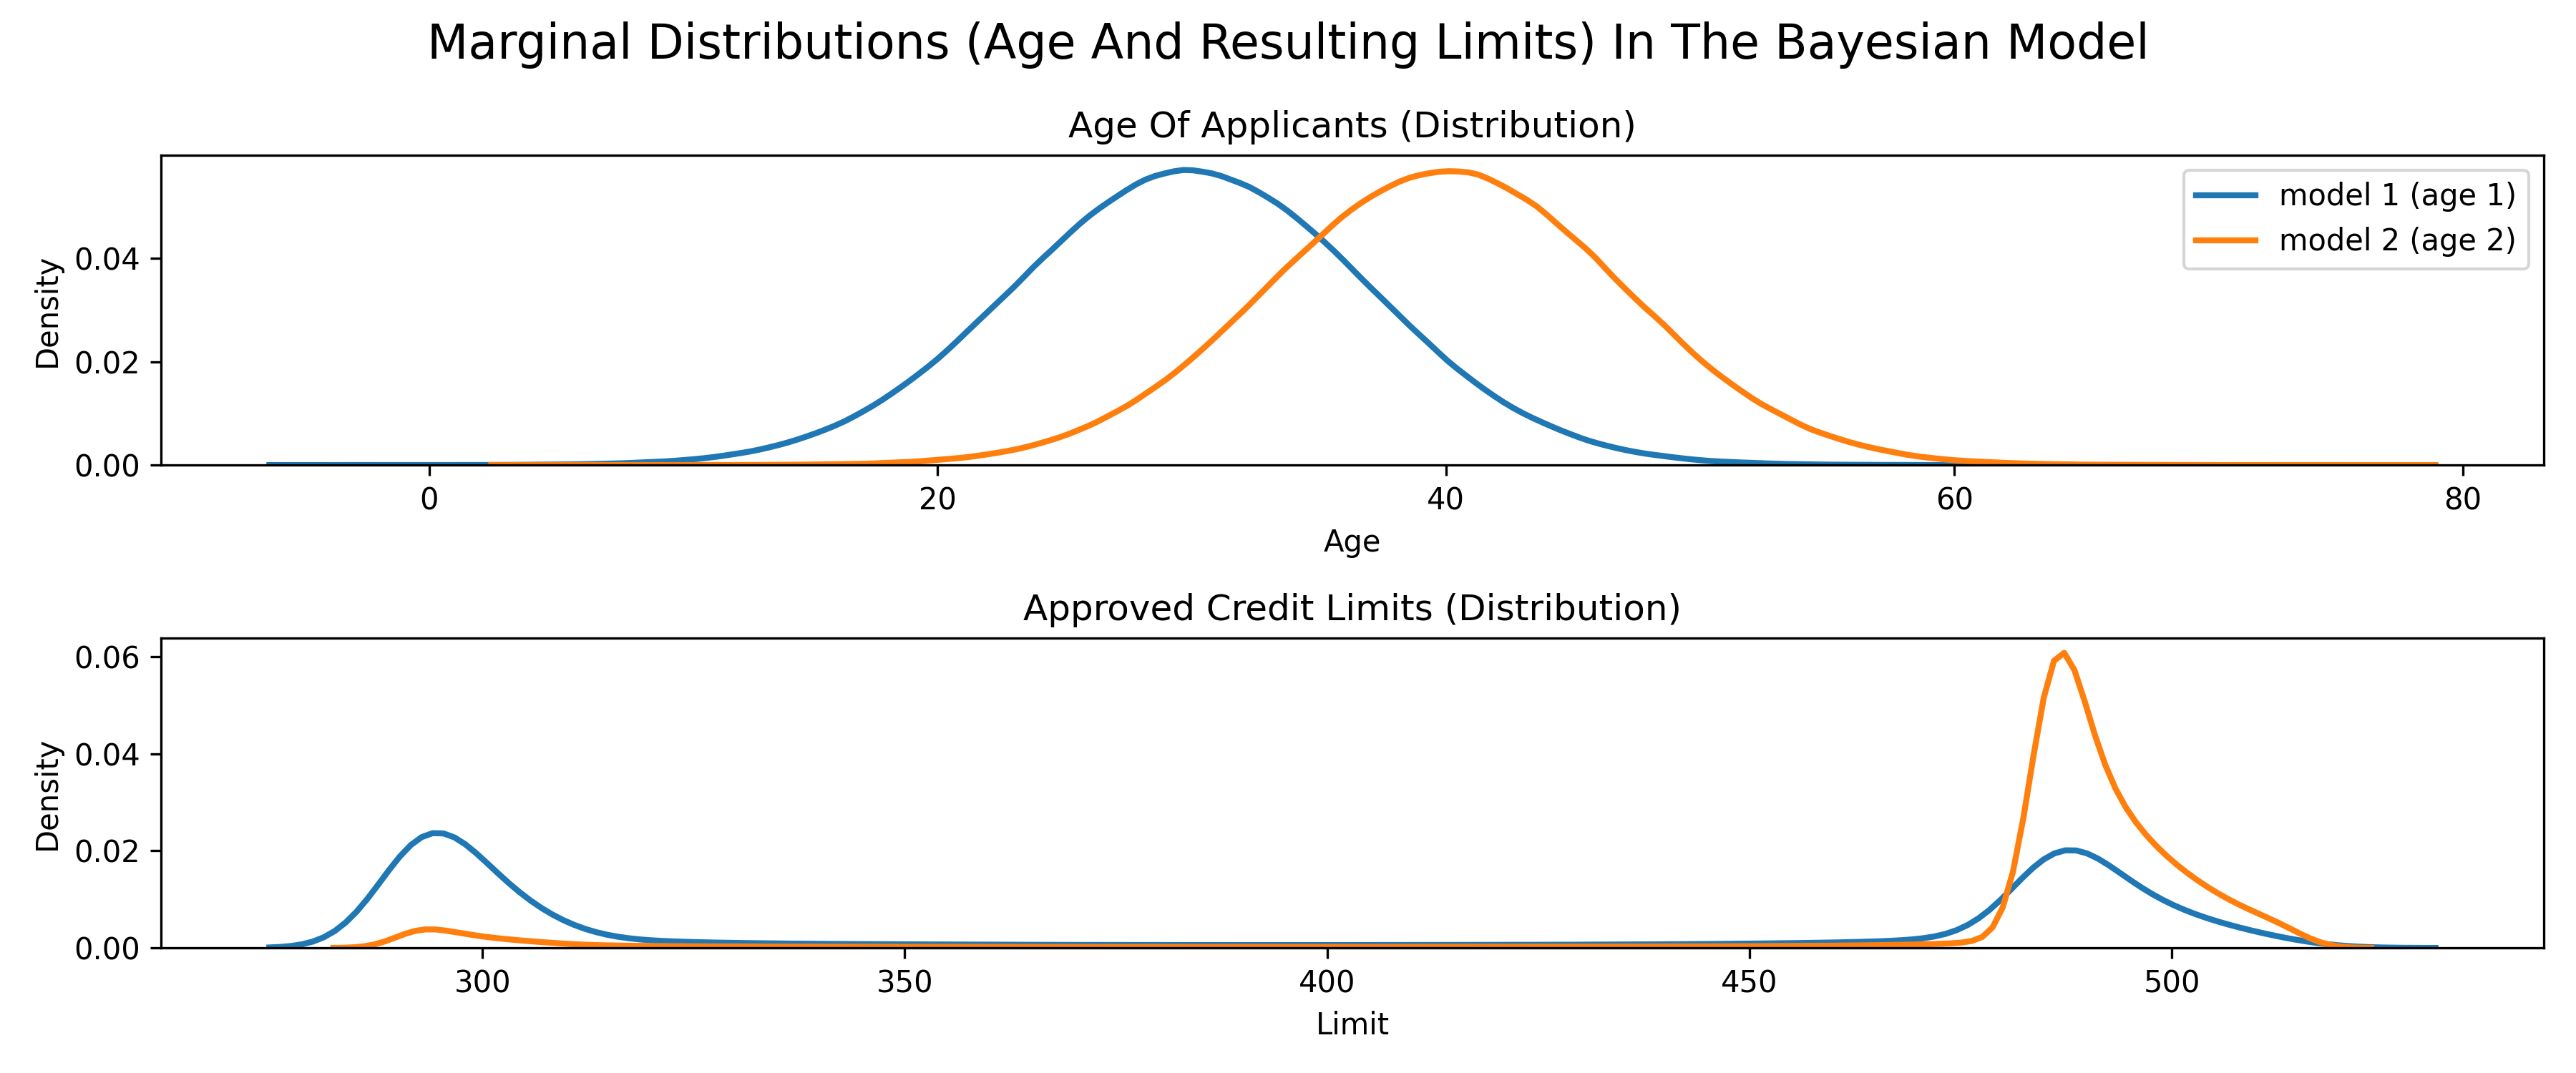

In [4]:
display(Image(filename="dce/marginal_distributions_age_hours.png"))

### Responsibility scores

We look at the results at two levels of granularity. First, we fix specific factual values for the inputs and sample from the expanded model, inspecting the resulting samples in the necessity and sufficiency worlds together with the point-wise scores. The total score is the mean of these point-wise scores. We do this conditional on each feature being intervened on in turn — first inspecting scores when age is the active antecedent, then the same for time of application.

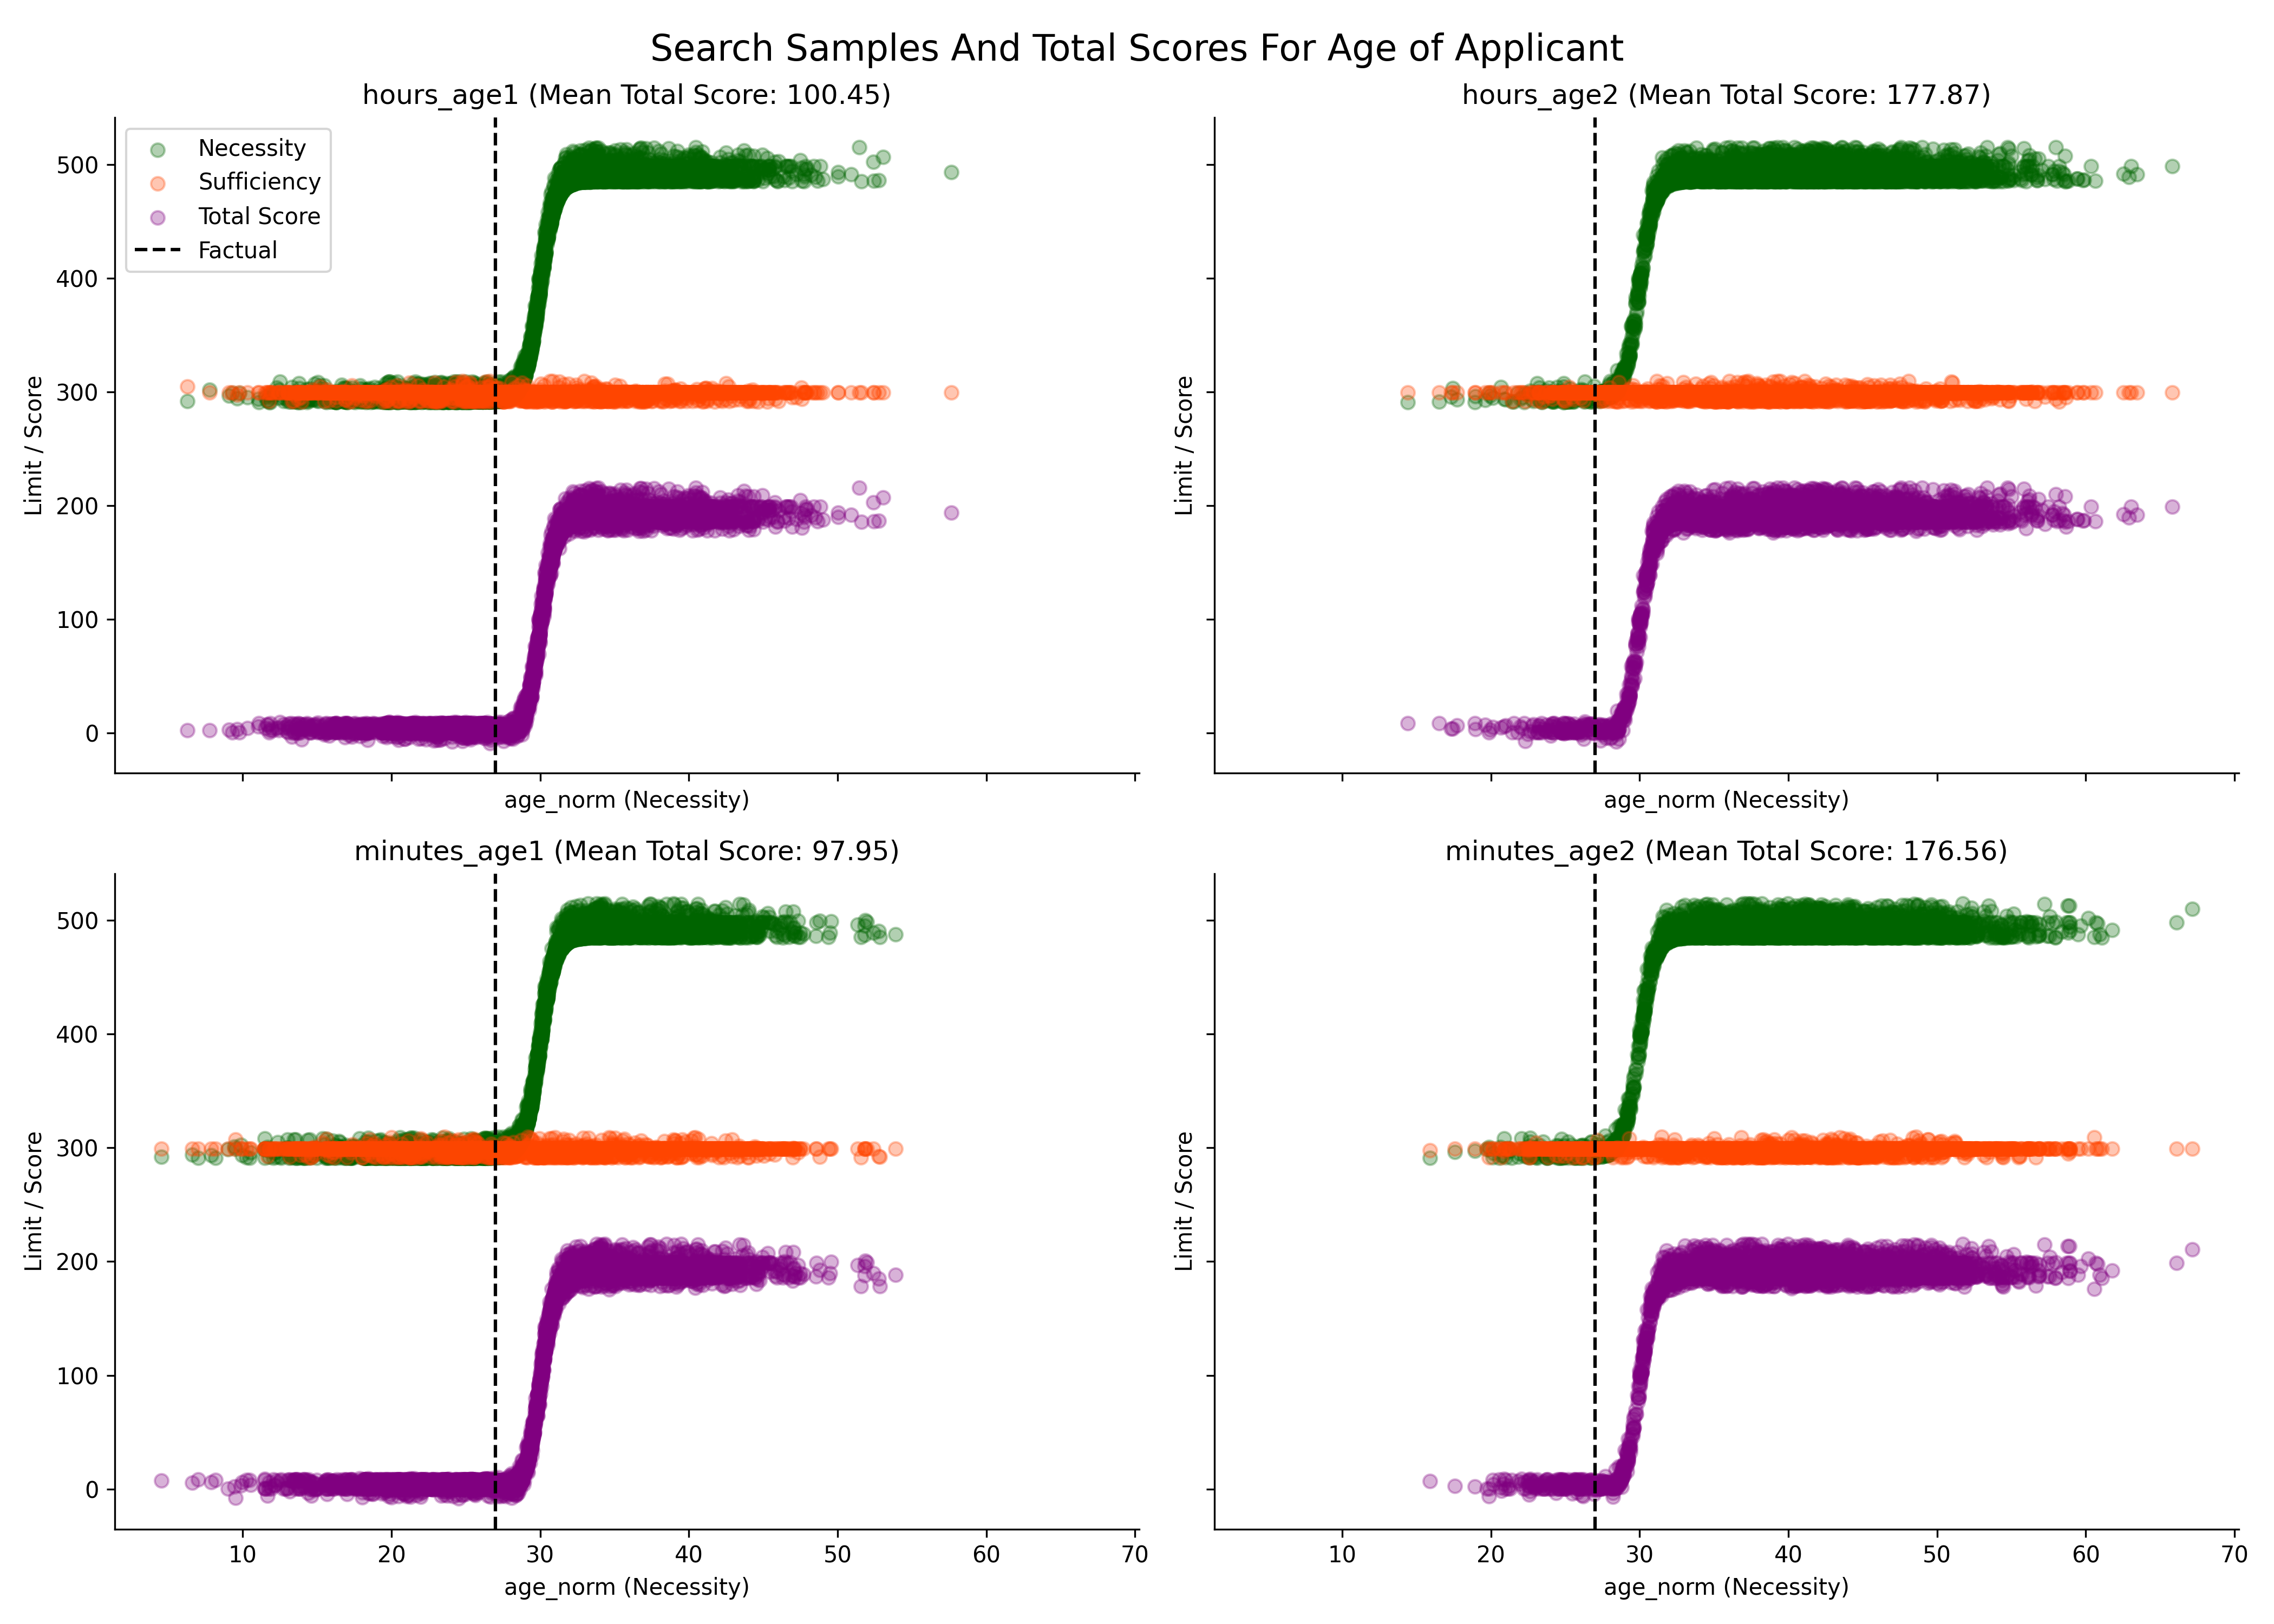

In [5]:
display(Image(filename="dce/search_samples_age_norm.png"))

In the sufficiency worlds the outcome does not change much, but it changes in the necessity world, and the change patterns roughly follow the deterministic curves plotted earlier. The difference between left and right reflects which prior was used for age: a more unusual factual age yields a higher score. The difference between rows (hour vs. minute scale) leaves the outcome distributions essentially unchanged.

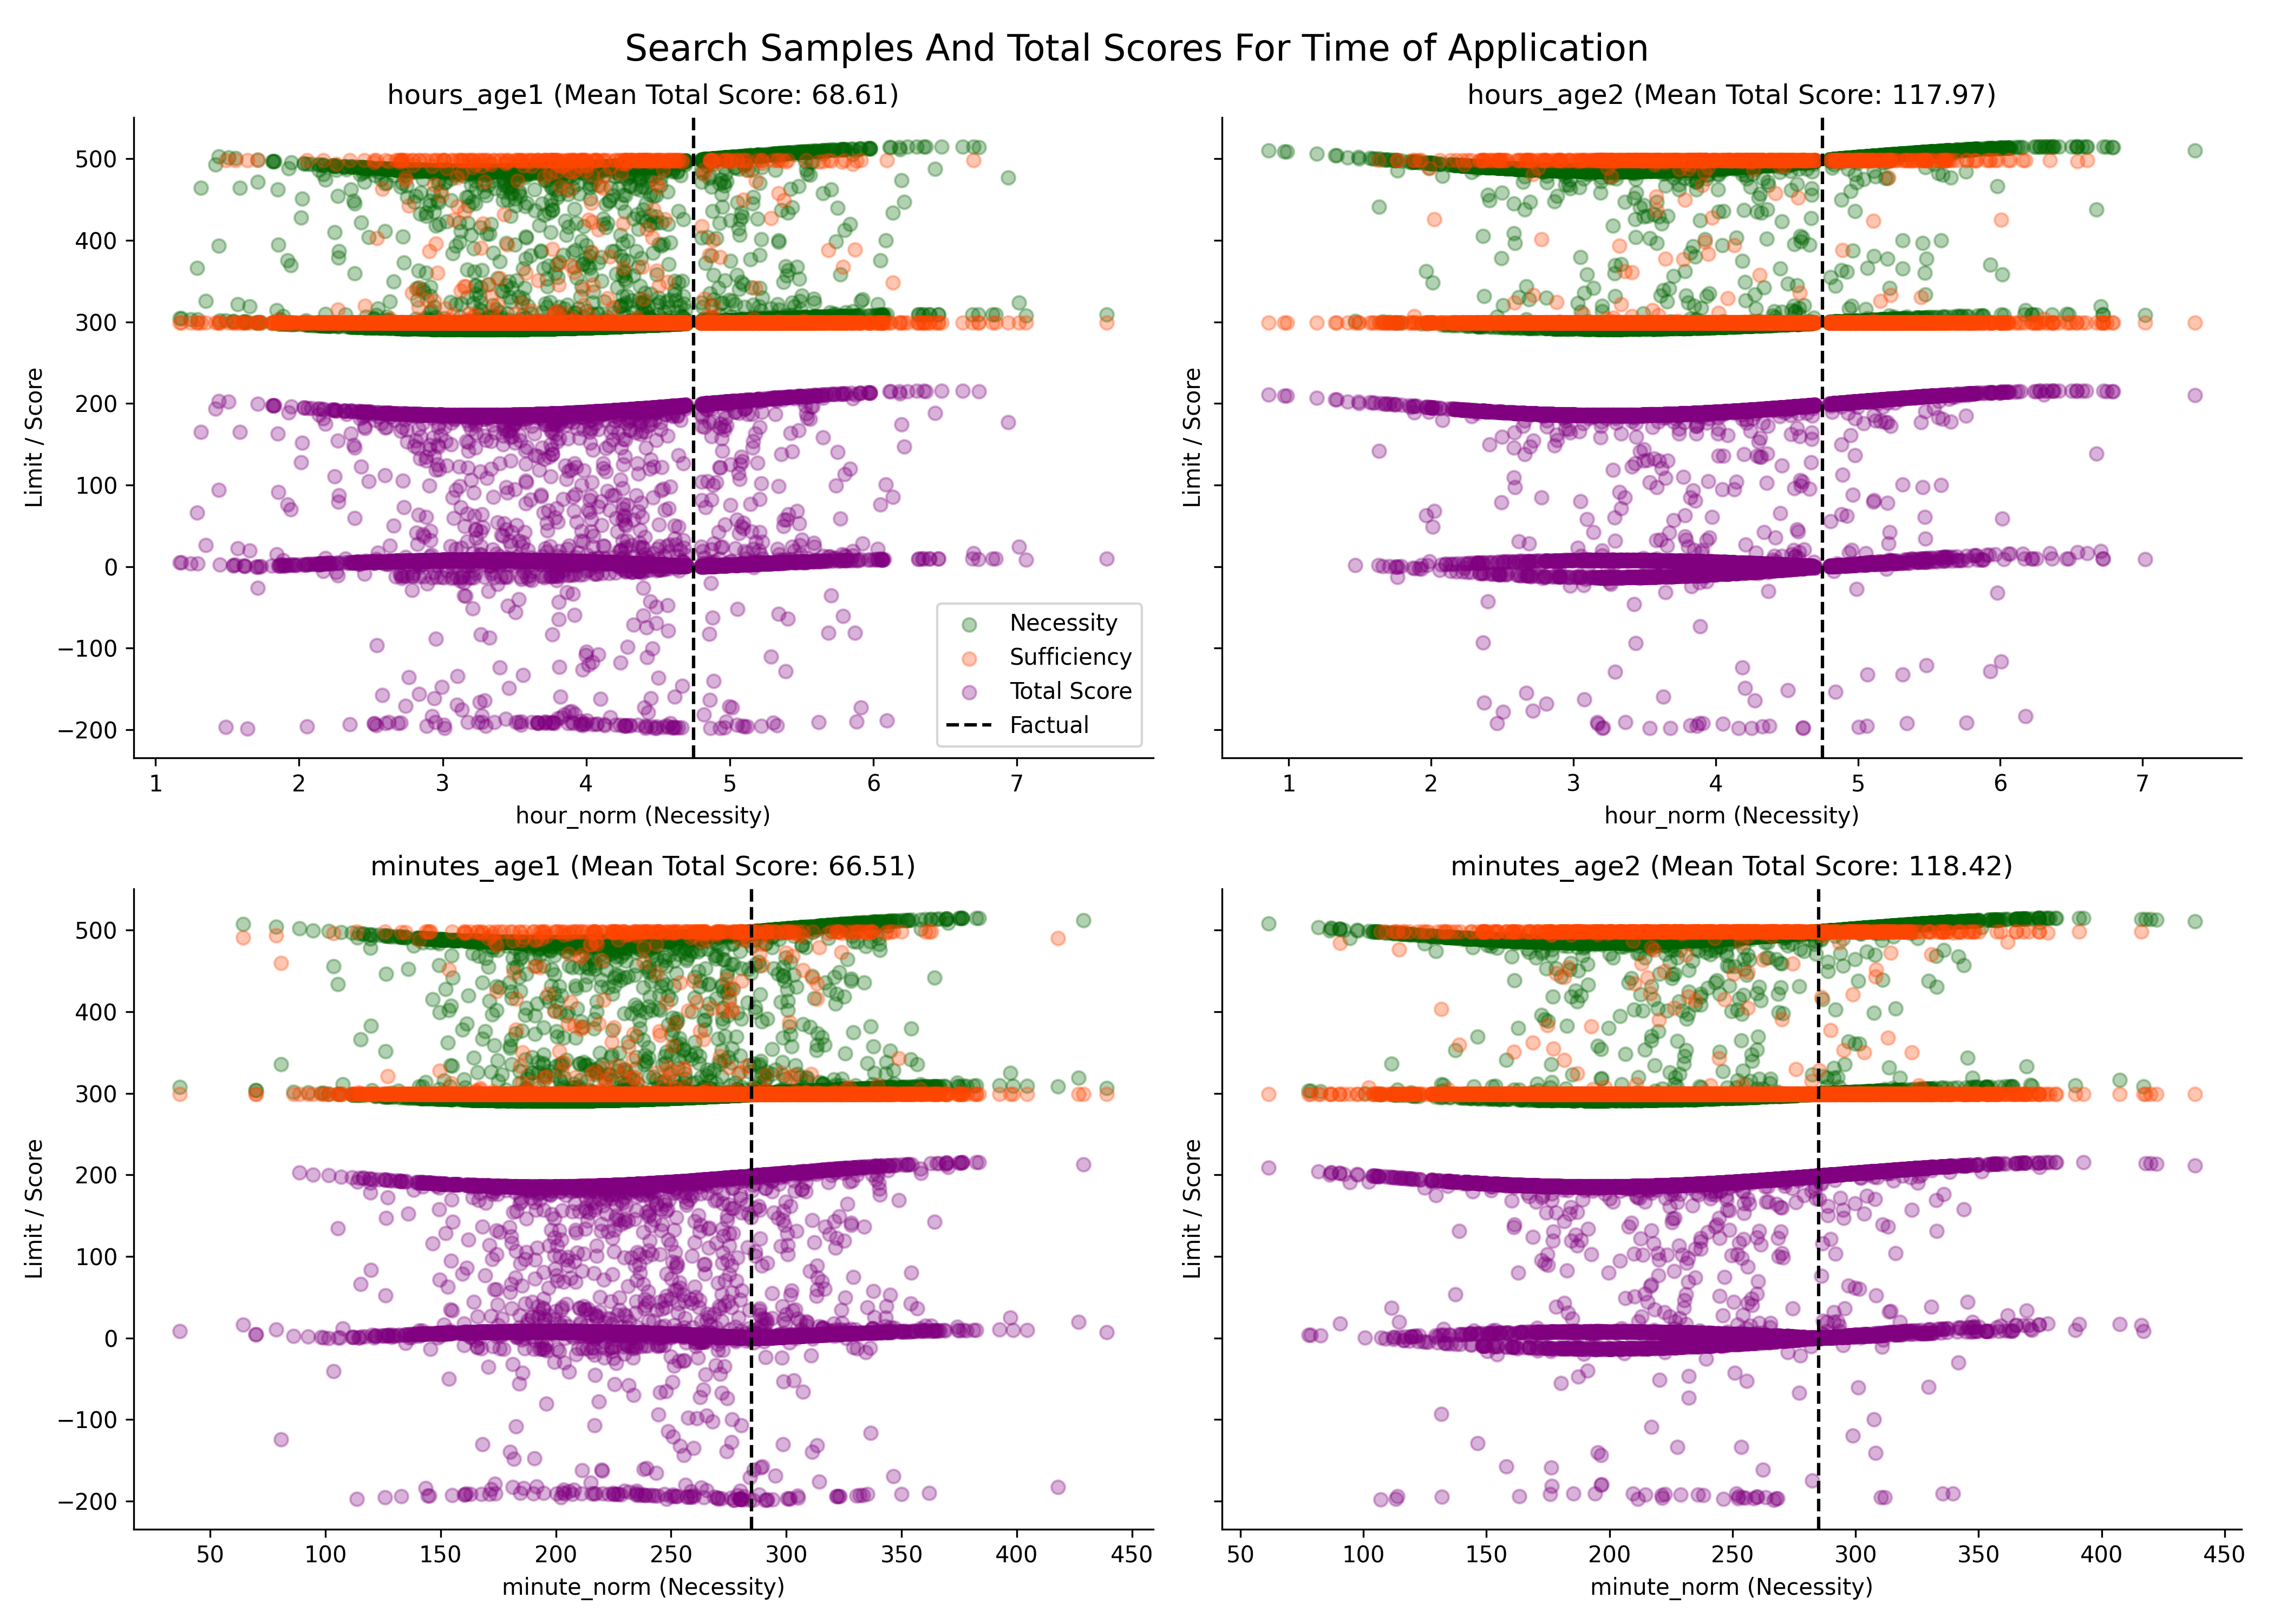

In [6]:
display(Image(filename="dce/search_samples_hour_norm.png"))

The plot layout is analogous. One difference: even in the sufficiency world the outcomes are sometimes quite different. This is because some sampling runs also resample age (for robustness), and age has a large impact, so time of application is not very sufficient for the credit limit on its own. The absolute changes in the outcome are also relatively small compared to those in the previous plot. Accordingly, the total scores are systematically lower for time of application than for age of applicant, which matches the intuition that age dominates.

Second, we compute responsibility scores across a range of inputs on a grid, and do the same for DCE. The PCI score is consistently higher for age, with individual values varying with how unusual the inputs are under the priors and what credit limits they produce in the necessity and sufficiency worlds.

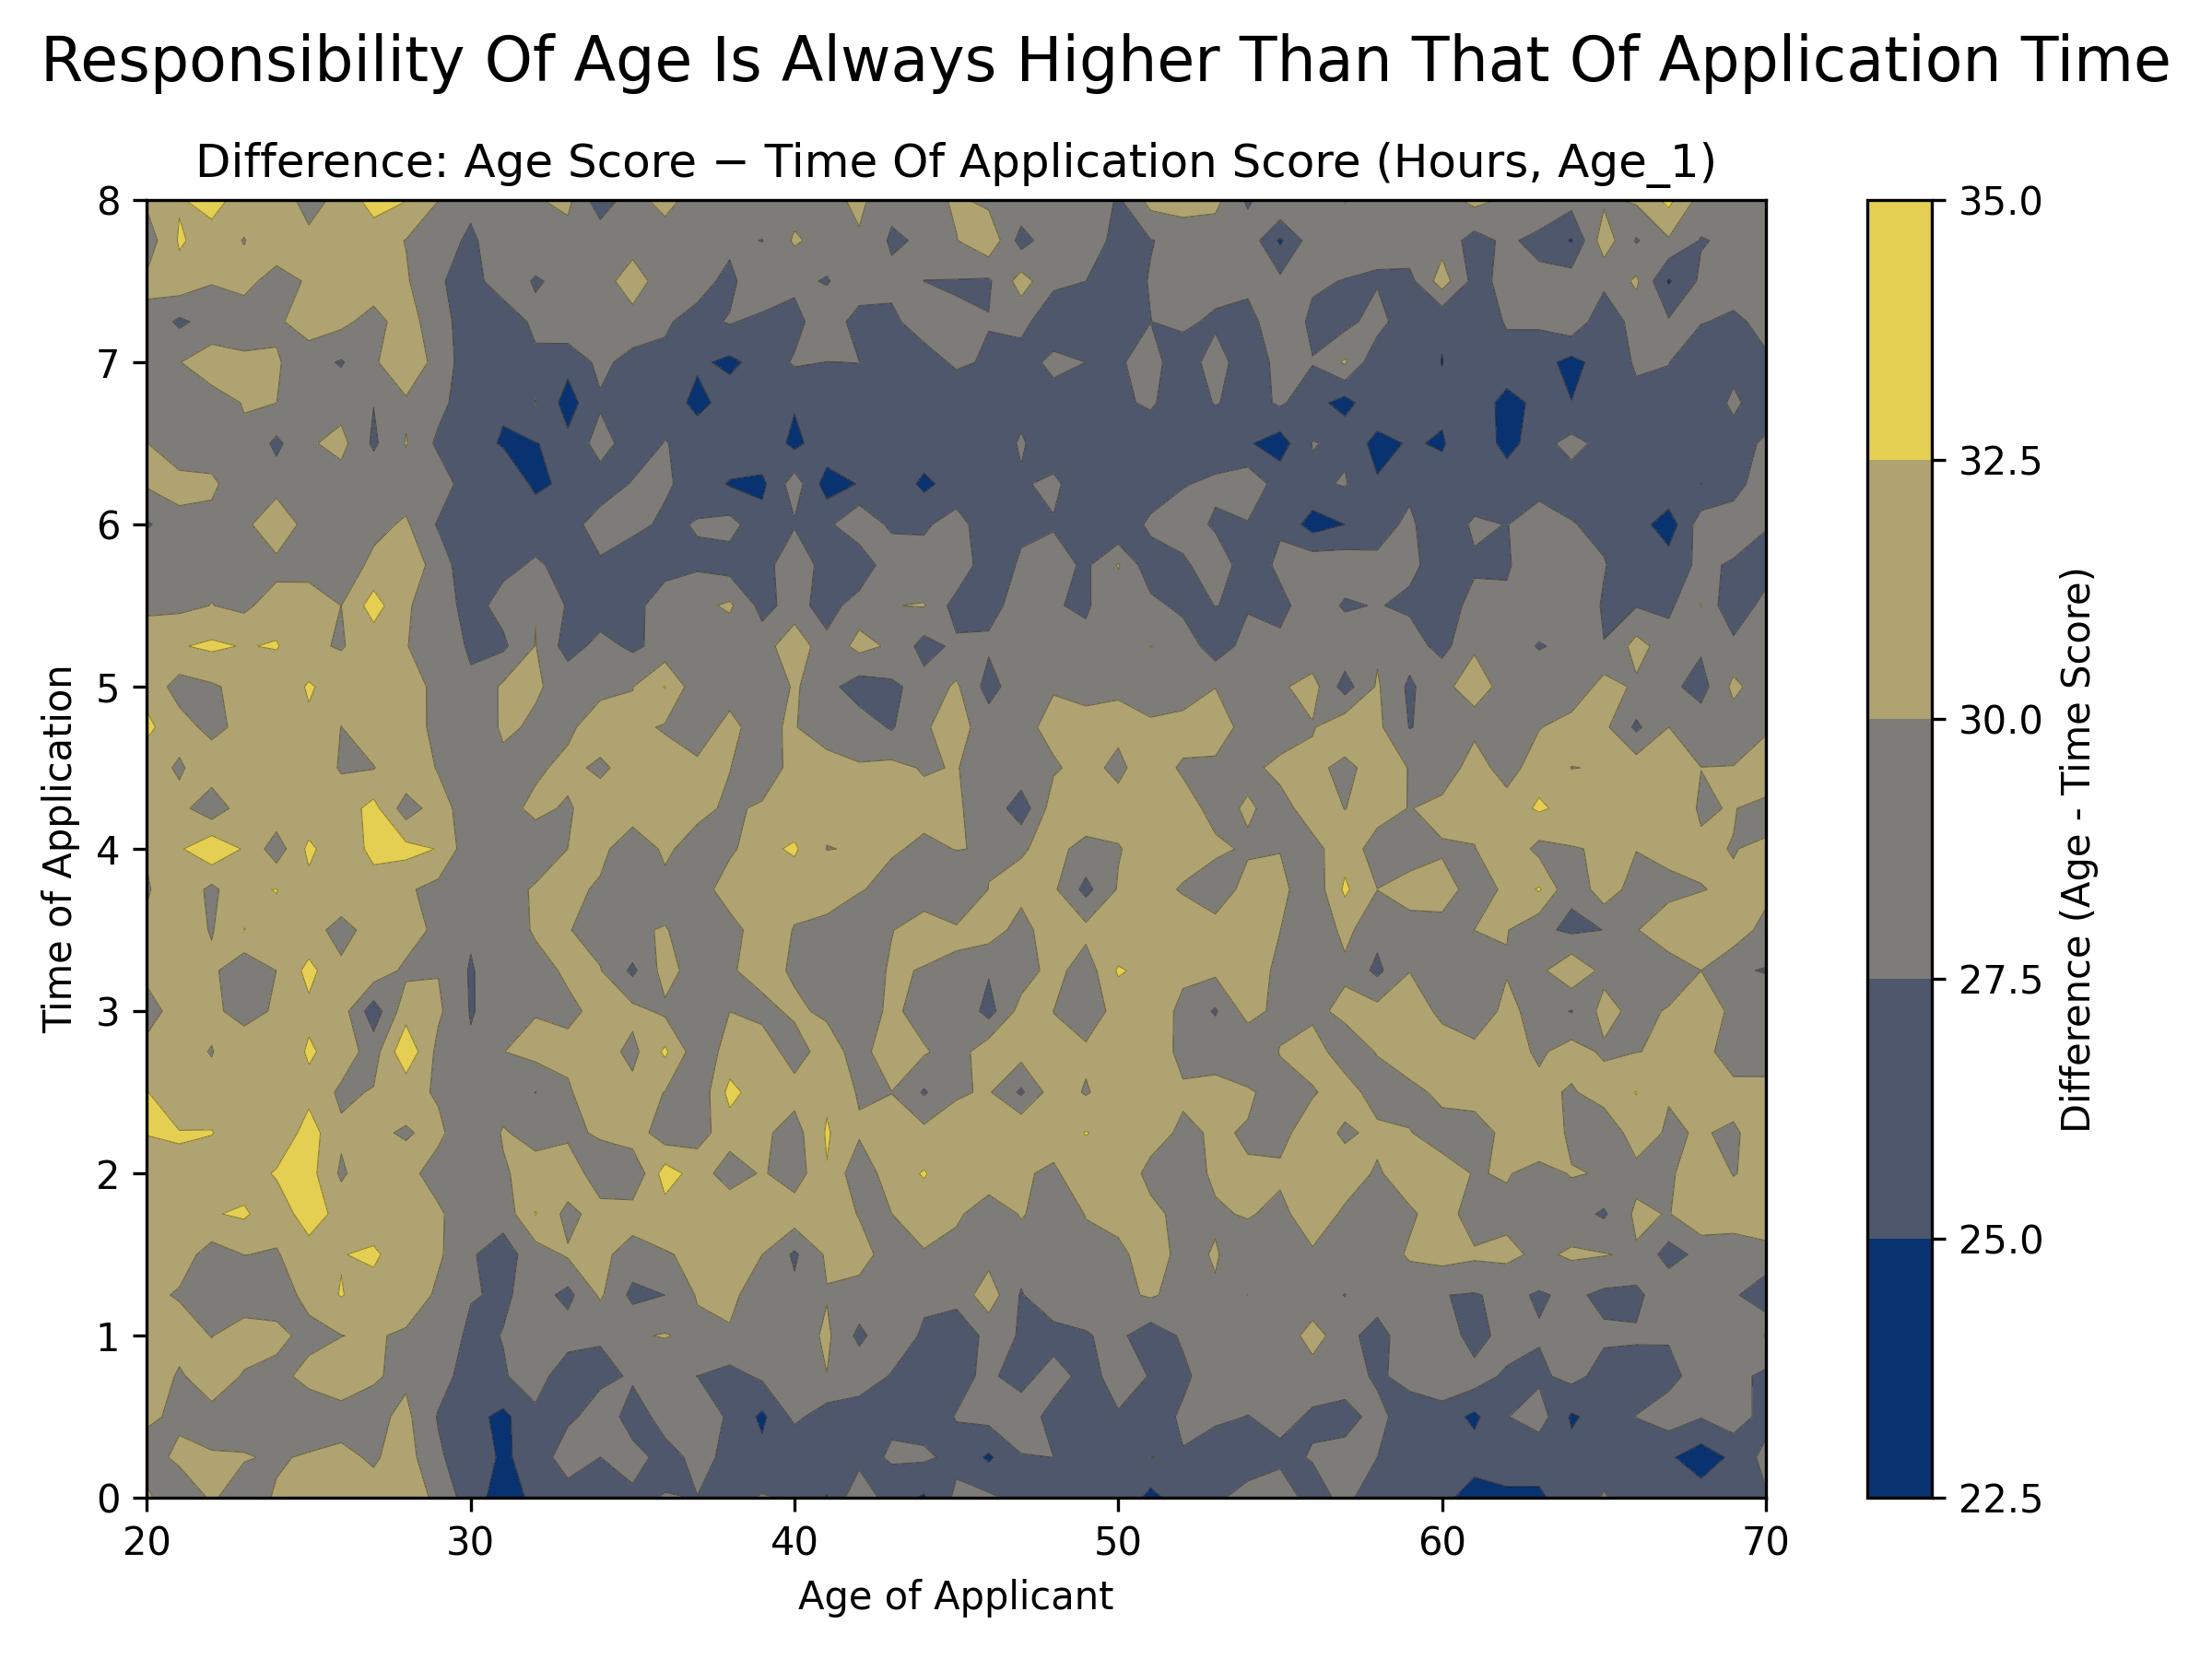

In [7]:
display(Image(filename="dce/contour_diff_hours_age_1.png"))

### Differential causal effects

By contrast, DCE scores are harder to interpret. On the hour scale, DCE for time of application is a sine wave whose absolute values exceed DCE for age over most of the grid — so DCE does not capture the intuition that age dominates time of application, since changes in time of application produce only minor outcome shifts while a change in age can have a much larger consequence.

Moreover, switching the scale from hours to minutes flattens DCE for time of application by roughly a factor of 60, illustrating that the score assigned to time of application is highly sensitive to input units.

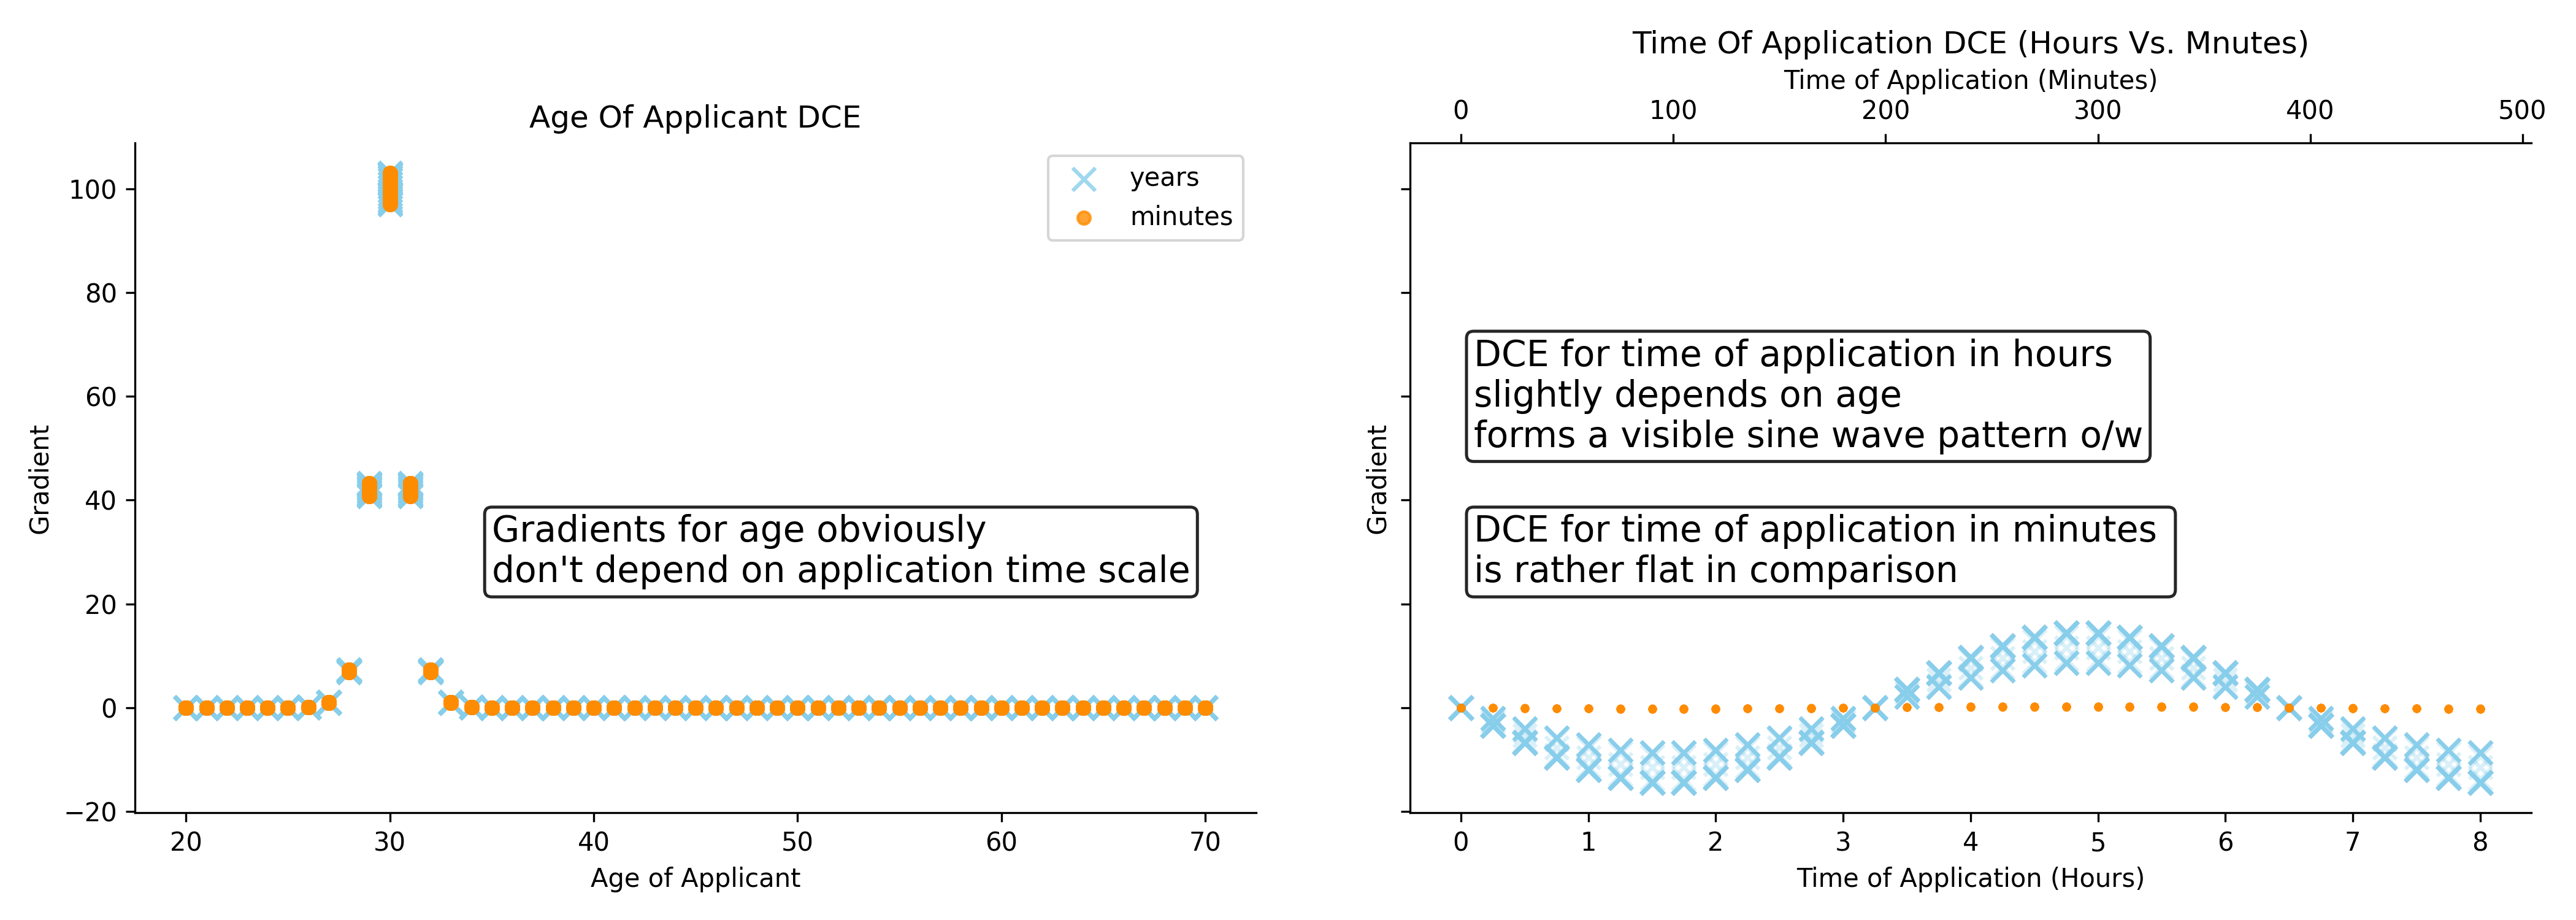

In [8]:
display(Image(filename="dce/dce_age_time_hours_minutes.png"))

## Code

### Models

In [9]:
def internal_model_hours(age_norm: torch.Tensor, hour_norm: torch.Tensor):
    steepness = 2  # smaller -> more gradual, larger -> steeper
    amplitude = 0.03
    peak_hour = 0  # 10 AM peak

    age_scaled = (age_norm - 30) * steepness

    sigmoid_transform = transforms.SigmoidTransform()
    affine_transform = transforms.AffineTransform(300, 200)  # scale=200, loc=300
    transform = transforms.ComposeTransform([sigmoid_transform, affine_transform])

    limit_base = pyro.deterministic("limit_base", transform(age_scaled))

    multiplier = 1.0 + amplitude * torch.sin(
        2 * torch.pi * (hour_norm - peak_hour) / 6.5 + torch.pi / 2
    )
    # move to 0 if between 18 and 9

    limit = pyro.deterministic("limit", multiplier * limit_base)

    return limit


def internal_model_minutes(age_norm: torch.Tensor, minute_norm: torch.Tensor):
    steepness = 2  # smaller -> more gradual, larger -> steeper
    amplitude = 0.03
    peak_minute = 0  # 10 AM peak

    age_scaled = (age_norm - 30) * steepness

    sigmoid_transform = transforms.SigmoidTransform()
    affine_transform = transforms.AffineTransform(300, 200)  # scale=200, loc=300
    transform = transforms.ComposeTransform([sigmoid_transform, affine_transform])

    limit_base = pyro.deterministic("limit_base", transform(age_scaled))

    multiplier = 1.0 + amplitude * torch.sin(
        2 * torch.pi * (minute_norm - peak_minute) / 390 + torch.pi / 2
    )
    # move to 0 if between 18 and 9

    limit = pyro.deterministic("limit", multiplier * limit_base)

    return limit

/tmp/claude-1000/ipykernel_56536/3298286588.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_norm=torch.tensor(age_space), hour_norm=torch.tensor(time)


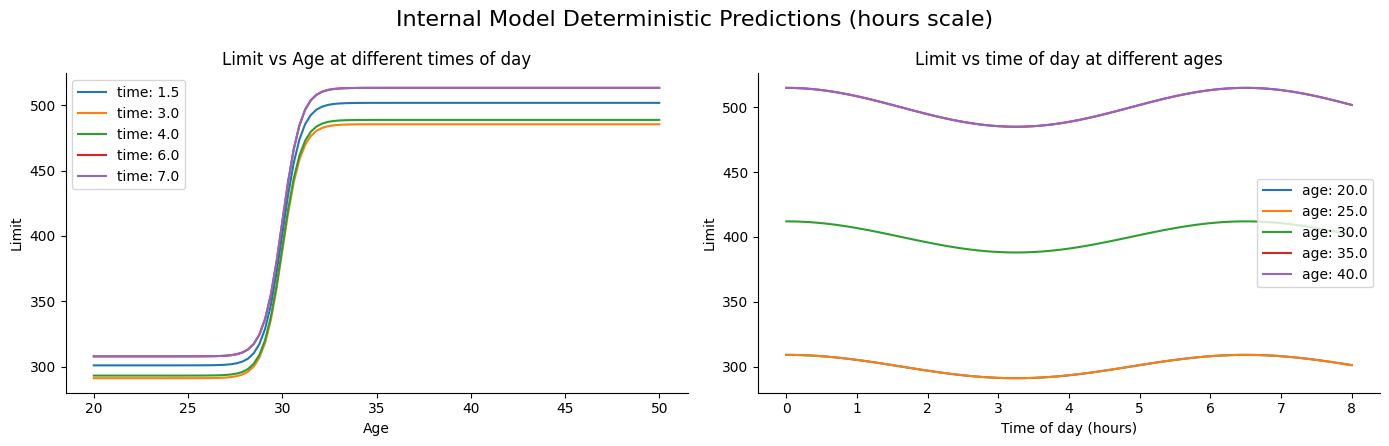

/tmp/claude-1000/ipykernel_56536/3298286588.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_norm=torch.tensor(age_space), minute_norm=torch.tensor(time)


In [10]:
# visualize impacts for the internal model (hours scale only; the minute scale is the
# same dependence modulo a linear reparameterisation, checked by the assertions below)

age_space = torch.linspace(20.0, 50.0, steps=100)
hour_space = torch.linspace(0, 8, steps=100)
minute_space = torch.linspace(0, 8 * 60, steps=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

hours = [1.5, 3.0, 4.0, 6.0, 7.0]
limits = {}
limits_age = {}
for time in hours:
    limits[time] = internal_model_hours(
        age_norm=torch.tensor(age_space), hour_norm=torch.tensor(time)
    ).numpy()
    axes[0].plot(age_space.numpy(), limits[time], label=f"time: {time}")

axes[0].set_xlabel("Age")
axes[0].set_ylabel("Limit")
axes[0].set_title("Limit vs Age at different times of day")
axes[0].legend()
sns.despine(ax=axes[0])

ages = [20.0, 25.0, 30.0, 35.0, 40.0]
for _age in ages:
    limits_age[_age] = internal_model_hours(
        age_norm=torch.tensor(_age), hour_norm=hour_space
    ).numpy()
    axes[1].plot(hour_space.numpy(), limits_age[_age], label=f"age: {_age}")

axes[1].set_xlabel("Time of day (hours)")
axes[1].set_ylabel("Limit")
axes[1].set_title("Limit vs time of day at different ages")
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle("Internal Model Deterministic Predictions (hours scale)", fontsize=16)
plt.tight_layout()
file_path = "dce/internal_model_predictions.png"
plt.savefig(file_path, dpi=300)
plt.show()

# Sanity check: the minute scale is the same dependence modulo a linear transform.
minutes = [h * 60 for h in hours]
limits_minutes = {}
limits_minutes_age = {}
for time in minutes:
    limits_minutes[time] = internal_model_minutes(
        age_norm=torch.tensor(age_space), minute_norm=torch.tensor(time)
    ).numpy()
for _age in ages:
    limits_minutes_age[_age] = internal_model_minutes(
        age_norm=torch.tensor(_age), minute_norm=minute_space
    ).numpy()
for key in limits.keys():
    np.testing.assert_allclose(limits[key], limits_minutes[key * 60], rtol=1e-5)
for key in limits_age.keys():
    np.testing.assert_allclose(limits_age[key], limits_minutes_age[key], rtol=1e-5)


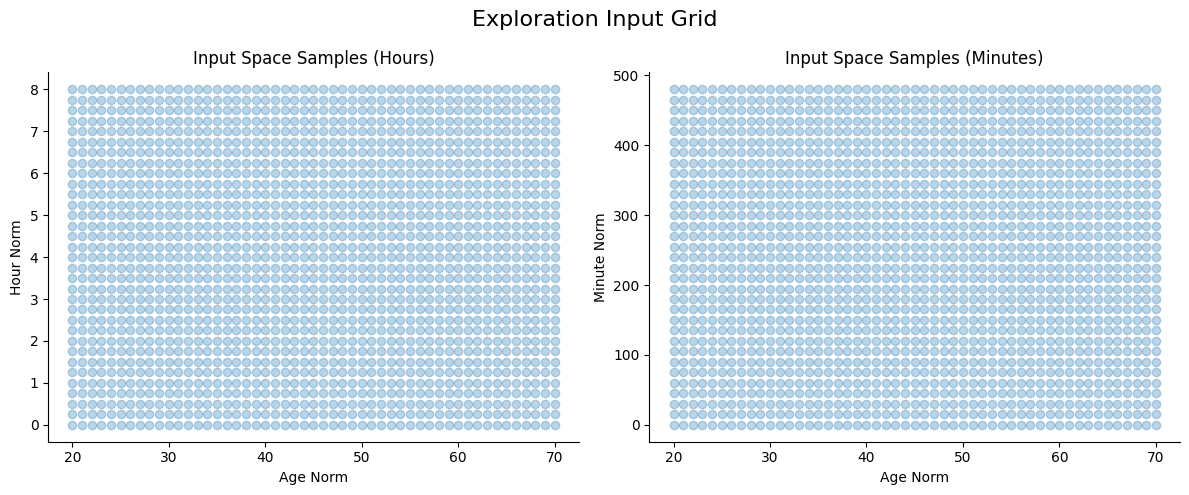

synth limits hours shape torch.Size([1683, 1, 1])
synth limits minutes shape torch.Size([1683, 1, 1])


In [11]:
# make synthetic data for future reference and
# build grids for further exploration

ages = torch.linspace(20.0, 70.0, steps=51)  # type: ignore
hours = torch.linspace(0.0, 8.0, steps=33)  # type: ignore
minutes = torch.linspace(0.0, 8.0 * 60, steps=33)  # type: ignore

# Build meshgrid
A, H = torch.meshgrid(ages, hours, indexing="ij")  # type: ignore
Am, M = torch.meshgrid(ages, minutes, indexing="ij")  # type: ignore

# Flatten and reshape to [N, 1, 1]
A_flat = A.reshape(-1, 1, 1)  # [51*33, 1, 1]
H_flat = H.reshape(-1, 1, 1)  # [51*33, 1, 1]

Am_flat = Am.reshape(-1, 1, 1)
M_flat = M.reshape(-1, 1, 1)

inputs_of_interest = {"age_norm": A_flat, "hour_norm": H_flat}
inputs_of_interest_minutes = {"age_norm": Am_flat, "minute_norm": M_flat}


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    inputs_of_interest["age_norm"].numpy().flatten(),
    inputs_of_interest["hour_norm"].numpy().flatten(),
    alpha=0.3,
)
axes[0].set_xlabel("Age Norm")
axes[0].set_ylabel("Hour Norm")
axes[0].set_title("Input Space Samples (Hours)")
sns.despine(ax=axes[0])

axes[1].scatter(
    inputs_of_interest_minutes["age_norm"].numpy().flatten(),
    inputs_of_interest_minutes["minute_norm"].numpy().flatten(),
    alpha=0.3,
)
axes[1].set_xlabel("Age Norm")
axes[1].set_ylabel("Minute Norm")
axes[1].set_title("Input Space Samples (Minutes)")
sns.despine(ax=axes[1])

plt.suptitle("Exploration Input Grid", fontsize=16)

plt.tight_layout()
plt.show()

# These are the evaluation grids
synthetic_limits_hours = internal_model_hours(**inputs_of_interest)
synthetic_limits_minutes = internal_model_minutes(**inputs_of_interest_minutes)


observations_dict_hours = {
    "continuous": {
        "limit": synthetic_limits_hours,
        "age_norm": inputs_of_interest["age_norm"],
        "hour_norm": inputs_of_interest["hour_norm"],
    },
    "categorical": {},
}

observations_dict_minutes = {
    "continuous": {
        "limit": synthetic_limits_minutes,
        "age_norm": inputs_of_interest_minutes["age_norm"],
        "minute_norm": inputs_of_interest_minutes["minute_norm"],
    },
    "categorical": {},
}


kwargs_iterable_hours = [
    {"observations_dict_hours": observations_dict_hours, "n_size": n_size}
]
kwargs_iterable_minutes = [
    {"observations_dict_minutes": observations_dict_minutes, "n_size": n_size}
]

print("synth limits hours shape", synthetic_limits_hours.shape)
print("synth limits minutes shape", synthetic_limits_minutes.shape)


n_size = 1

In [12]:
# now add the uncertainty layer

AGE_MEAN_1 = 30.0
AGE_MEAN_2 = 40.0
AGE_STD = 7.0

HOUR_MEAN = 4.0
HOUR_STD = 0.9

MINUTE_MEAN = HOUR_MEAN * 60
MINUTE_STD = HOUR_STD * 60


def make_wrapped_model(
    internal_model,
    latent_name,
    latent_mean,
    latent_std,
    default_AGE_MEAN,
):
    """
    Creates a Pyro model wrapper with a configurable default AGE_MEAN.
    """

    def model(
        kwargs_iterable=[
            {"observations_dict": None, "n_size": n_size},
            dict(),
            dict(),
        ],
        AGE_MEAN=default_AGE_MEAN,  # <- default baked in here
    ):
        batch_size = kwargs_iterable[0]["n_size"]

        with pyro.plate("sample", size=batch_size, dim=-3):
            age_norm = pyro.sample("age_norm", dist.Normal(AGE_MEAN, AGE_STD))
            latent = pyro.sample(latent_name, dist.Normal(latent_mean, latent_std))

        return internal_model(age_norm=age_norm, **{latent_name: latent})

    return model


wrapped_hours_age1 = make_wrapped_model(
    internal_model=internal_model_hours,
    latent_name="hour_norm",
    latent_mean=HOUR_MEAN,
    latent_std=HOUR_STD,
    default_AGE_MEAN=AGE_MEAN_1,
)

wrapped_hours_age2 = make_wrapped_model(
    internal_model=internal_model_hours,
    latent_name="hour_norm",
    latent_mean=HOUR_MEAN,
    latent_std=HOUR_STD,
    default_AGE_MEAN=AGE_MEAN_2,
)

wrapped_minutes_age1 = make_wrapped_model(
    internal_model=internal_model_minutes,
    latent_name="minute_norm",
    latent_mean=MINUTE_MEAN,
    latent_std=MINUTE_STD,
    default_AGE_MEAN=AGE_MEAN_1,
)

wrapped_minutes_age2 = make_wrapped_model(
    internal_model=internal_model_minutes,
    latent_name="minute_norm",
    latent_mean=MINUTE_MEAN,
    latent_std=MINUTE_STD,
    default_AGE_MEAN=AGE_MEAN_2,
)

In [13]:
# run the wrapped models with tracing
# take a look at the uncertainties


def run_model_with_trace(model, kwargs_iterable, sample_size):
    with pyro.plate("samples", size=sample_size, dim=-4):
        with pyro.poutine.trace() as tr:
            result = model(kwargs_iterable=kwargs_iterable)
    return tr, result


models = {
    "hours_age1": wrapped_hours_age1,
    "hours_age2": wrapped_hours_age2,
    "minutes_age1": wrapped_minutes_age1,
    "minutes_age2": wrapped_minutes_age2,
}

kwargs_map = {
    "hours_age1": kwargs_iterable_hours,
    "hours_age2": kwargs_iterable_hours,
    "minutes_age1": kwargs_iterable_minutes,
    "minutes_age2": kwargs_iterable_minutes,
}


traces = {}
results = {}

for name, model in models.items():
    tr, res = run_model_with_trace(model, kwargs_map[name], sample_size)
    traces[name] = tr
    results[name] = res

In [14]:
def plot_traces_hours_minutes_kde(
    traces_hours: dict,
    traces_minutes: dict,
    keys_hours=["age_norm", "hour_norm", "limit"],
    keys_minutes=["age_norm", "minute_norm", "limit"],
):
    """
    Same as your histogram function, but plots KDE density curves instead.
    """

    fig, axes = plt.subplots(2, len(keys_hours), figsize=(16, 8))

    # ----- ROW 0: HOURS -----
    for col, key in enumerate(keys_hours):
        ax = axes[0, col]
        for label, trace in traces_hours.items():
            values = trace.trace.nodes[key]["value"].detach().cpu().numpy().flatten()

            sns.kdeplot(
                values,
                ax=ax,
                label=f"{label}",
                linewidth=2,
            )

        ax.set_title(f"{key} (Hours)")
        ax.set_xlabel(key)
        ax.set_ylabel("Density")
        ax.legend()
        sns.despine(ax=ax)

    # ----- ROW 1: MINUTES -----
    for col, key in enumerate(keys_minutes):
        ax = axes[1, col]
        for label, trace in traces_minutes.items():
            values = trace.trace.nodes[key]["value"].detach().cpu().numpy().flatten()

            sns.kdeplot(
                values,
                ax=ax,
                label=f"{label}",
                linewidth=2,
            )

        ax.set_title(f"{key} (Minutes)")
        ax.set_xlabel(key)
        ax.set_ylabel("Density")
        ax.legend()
        sns.despine(ax=ax)

    plt.suptitle("Marginal Distributions In The Bayesian Model", fontsize=16)
    plt.tight_layout()
    plt.show()

In [15]:
traces["hours_age2"].trace.nodes.keys()

odict_keys(['sample', 'age_norm', 'hour_norm', 'limit_base', 'limit'])

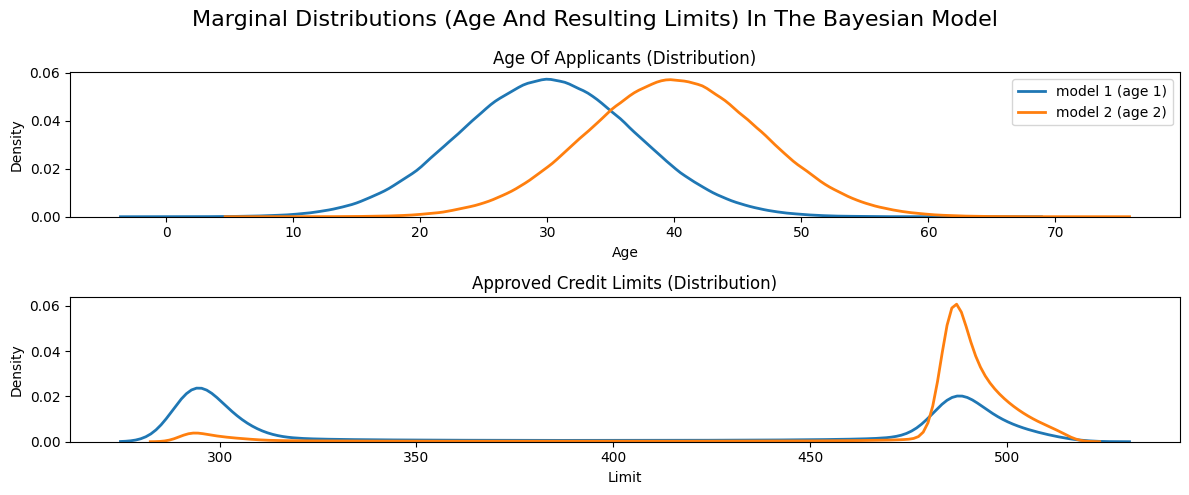

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))  # <-- create one axes


traces_hours = {
    "model 1 (age 1)": traces["hours_age1"],
    "model 2 (age 2)": traces["hours_age2"],
}


for label, trace in traces_hours.items():
    values = trace.trace.nodes["age_norm"]["value"].detach().cpu().numpy().flatten()

    sns.kdeplot(
        values,
        ax=axes[0],
        label=f"{label}",
        linewidth=2,
    )

axes[0].set_title("Age Of Applicants (Distribution)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend()

for label, trace in traces_hours.items():
    values = trace.trace.nodes["limit"]["value"].detach().cpu().numpy().flatten()

    sns.kdeplot(
        values,
        ax=axes[1],
        label=f"{label}",
        linewidth=2,
    )

axes[1].set_title("Approved Credit Limits (Distribution)")
axes[1].set_xlabel("Limit")
axes[1].set_ylabel("Density")


plt.suptitle(
    "Marginal Distributions (Age And Resulting Limits) In The Bayesian Model",
    fontsize=16,
)
plt.tight_layout()
fig_path = "dce/marginal_distributions_age_hours.png"
plt.savefig(fig_path, dpi=300)
plt.show()

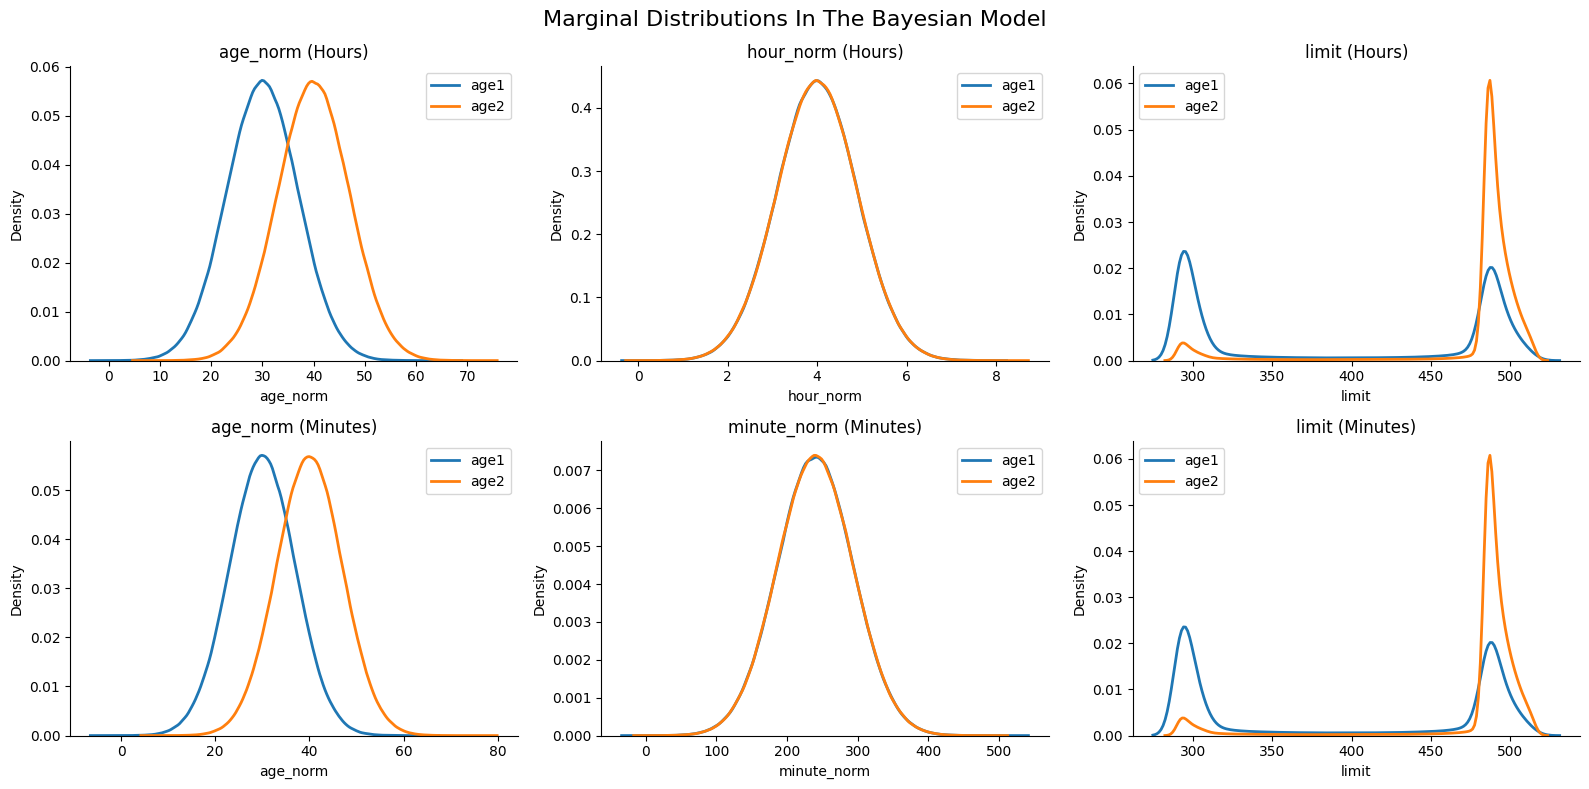

In [17]:
traces_hours = {
    "age1": traces["hours_age1"],
    "age2": traces["hours_age2"],
}

traces_minutes = {
    "age1": traces["minutes_age1"],
    "age2": traces["minutes_age2"],
}

plot_traces_hours_minutes_kde(traces_hours, traces_minutes)

### PCI search

In [18]:
def make_searchable_model(
    wrapped_model,
    sites_of_interest,
    suspects,
    outcome_variable="limit",
):
    return SearchableModel(
        structured_model=wrapped_model,
        sites_of_interest=sites_of_interest,
        suspects=suspects,
        outcome_variable=outcome_variable,
    )


model_configs = {
    "hours_age1": {
        "wrapped": wrapped_hours_age1,
        "sites": ["age_norm", "hour_norm"],
        "suspects": ["age_norm", "hour_norm"],
    },
    "hours_age2": {
        "wrapped": wrapped_hours_age2,
        "sites": ["age_norm", "hour_norm"],
        "suspects": ["age_norm", "hour_norm"],
    },
    "minutes_age1": {
        "wrapped": wrapped_minutes_age1,
        "sites": ["age_norm", "minute_norm"],
        "suspects": ["age_norm", "minute_norm"],
    },
    "minutes_age2": {
        "wrapped": wrapped_minutes_age2,
        "sites": ["age_norm", "minute_norm"],
        "suspects": ["age_norm", "minute_norm"],
    },
}

obs_map = {
    "hours_age1": observations_dict_hours,
    "hours_age2": observations_dict_hours,
    "minutes_age1": observations_dict_minutes,
    "minutes_age2": observations_dict_minutes,
}

searchable_models = {}

for name, cfg in model_configs.items():
    searchable_models[name] = make_searchable_model(
        wrapped_model=cfg["wrapped"],
        sites_of_interest=cfg["sites"],
        suspects=cfg["suspects"],
        outcome_variable="limit",
    )

samplers = {}

for name, searchable in searchable_models.items():
    samplers[name] = ThinSearchSampler(
        structured_model=searchable,
        conditioned_alternatives=True,
        factual_exclusion=True,
    )


cache_file = "search_results.pkl"

# Load cache if it exists
if os.path.exists(cache_file):
    with open(cache_file, "rb") as f:
        search_results = pickle.load(f)
else:
    search_results = {}


for name, sampler in samplers.items():
    if name not in search_results:
        print(f"Sampling for {name}...")
        search_results[name] = sampler.sample(obs_map[name], num_samples=num_search_samples)
    else:
        print(f"Using cached result for {name}")

# Save updated cache
with open(cache_file, "wb") as f:  # type: ignore
    pickle.dump(search_results, f)

Using cached result for hours_age1
Using cached result for hours_age2
Using cached result for minutes_age1
Using cached result for minutes_age2


In [19]:
suspects_map = {
    "hours_age1": ["age_norm", "hour_norm"],
    "hours_age2": ["age_norm", "hour_norm"],
    "minutes_age1": ["age_norm", "minute_norm"],
    "minutes_age2": ["age_norm", "minute_norm"],
}

factuals_map = {
    "hours_age1": synthetic_limits_hours,
    "hours_age2": synthetic_limits_hours,
    "minutes_age1": synthetic_limits_minutes,
    "minutes_age2": synthetic_limits_minutes,
}


def compute_suspect_scores(
    results_dict,  # output from search_sampler.sample
    suspects,  # list of suspect variable names
    factual_outcomes,  # e.g., synthetic_limits_hours or synthetic_limits_minutes
):
    conditioned_samples = {}
    suspect_scores = {}

    for suspect in suspects:
        conditioned_samples[suspect] = condition_on_interventional_regime(
            results_dictionary=results_dict,
            reference_variable_names=[suspect],
            antecedent_regimes={suspect: True},
            witness_regimes={suspect: False},
        )

        limit_suff = conditioned_samples[suspect]["regime_sufficiency"][
            "limit"
        ].detach()
        limit_nec = conditioned_samples[suspect]["regime_necessity"]["limit"]

        scores = abs_diff_score(
            suff_outcomes=limit_suff,
            nec_outcomes=limit_nec,
            factual_outcomes=factual_outcomes,
        )

        suspect_scores[suspect] = scores

    return suspect_scores


all_suspect_scores = {}

for name, results in search_results.items():
    all_suspect_scores[name] = compute_suspect_scores(
        results_dict=results,
        suspects=suspects_map[name],
        factual_outcomes=factuals_map[name],
    )

In [20]:
all_conditioned_samples = {}

for name, results in search_results.items():
    suspects = suspects_map[name]
    conditioned_samples = {}
    for suspect in suspects:
        conditioned_samples[suspect] = condition_on_interventional_regime(
            results_dictionary=results,
            reference_variable_names=[suspect],
            antecedent_regimes={suspect: True},
            witness_regimes={suspect: False},
        )
    all_conditioned_samples[name] = conditioned_samples

obs_map_for_plotting = {
    "hours_age1": observations_dict_hours,
    "hours_age2": observations_dict_hours,
    "minutes_age1": observations_dict_minutes,
    "minutes_age2": observations_dict_minutes,
}

### Inspect responsibility scores across models

In [21]:
def plot_mechanism_combined(
    all_conditioned_samples,
    all_suspect_scores,
    factuals,
    model_name="hours_age1",
    index_of_interest=250,
    panels=(("age_norm", "Age"), ("hour_norm", "Time of application")),
):
    """Single-row necessity / sufficiency / total-score scatter for one model,
    one panel per suspect (age | time). Replaces the earlier 2x2-per-suspect grids:
    the cross-unit and cross-prior robustness is reported in the means table instead."""
    fig, axes = plt.subplots(1, len(panels), figsize=(14, 5), sharey=True)
    conditioned = all_conditioned_samples[model_name]
    scores = all_suspect_scores[model_name]
    for ax, (suspect, nice) in zip(axes, panels):
        factual = factuals[model_name][suspect]
        nec_vals = conditioned[suspect]["regime_necessity"][suspect][
            :, index_of_interest, ...
        ]
        limit_nec = conditioned[suspect]["regime_necessity"]["limit"][
            :, index_of_interest, ...
        ]
        limit_suff = conditioned[suspect]["regime_sufficiency"]["limit"][
            :, index_of_interest, ...
        ]
        total_scores = scores[suspect]["total"][:, index_of_interest, ...]
        mean_total = total_scores.nanmean().item()
        ax.scatter(
            nec_vals.numpy().flatten(),
            limit_nec.numpy().flatten(),
            alpha=0.3,
            c="darkgreen",
            label="Necessity world",
        )
        ax.scatter(
            nec_vals.numpy().flatten(),
            limit_suff.numpy().flatten(),
            alpha=0.3,
            c="orangered",
            label="Sufficiency world",
        )
        ax.scatter(
            nec_vals.numpy().flatten(),
            total_scores.numpy().flatten(),
            alpha=0.3,
            c="purple",
            label="Total score",
        )
        ax.axvline(factual, color="black", linestyle="--", label="Factual")
        ax.set_xlabel(f"{nice} (necessity-world value)")
        ax.set_title(f"{nice} suspect (mean total score: {mean_total:.2f})")
        sns.despine(ax=ax)
    axes[0].set_ylabel("Limit / score")
    axes[0].legend()
    plt.suptitle(
        "PCI Search: Necessity, Sufficiency, and Total Score (age-30 prior, hours)",
        fontsize=16,
    )
    plt.tight_layout()
    file_path = "dce/search_samples_combined.png"
    plt.savefig(file_path, dpi=300)
    plt.show()


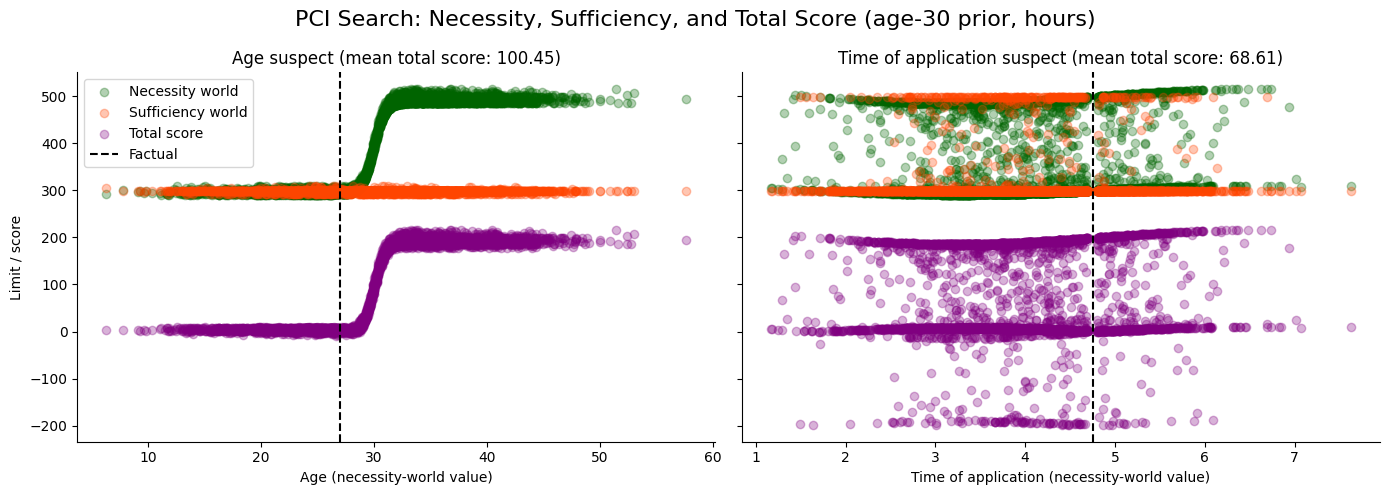

In [22]:
index_of_interest = 250

factuals = {}  # type: ignore
for name, obs in obs_map_for_plotting.items():
    factuals[name] = {}
    for var in obs["continuous"].keys():
        factuals[name][var] = obs["continuous"][var][index_of_interest, ...].item()

plot_mechanism_combined(
    all_conditioned_samples=all_conditioned_samples,
    all_suspect_scores=all_suspect_scores,
    factuals=factuals,
    model_name="hours_age1",
    index_of_interest=index_of_interest,
)


In [23]:
# Mean total scores at the factual index, for the robustness table in the paper.
# Rows: age suspect, time suspect; columns: {hours, minutes} x {age-30 (age1), age-40 (age2)}.
suspect_label = {"age_norm": "age", "hour_norm": "time", "minute_norm": "time"}
table_rows = {"age": {}, "time": {}}
for model_name in ["hours_age1", "minutes_age1", "hours_age2", "minutes_age2"]:
    for suspect, scores in all_suspect_scores[model_name].items():
        m = scores["total"][:, index_of_interest, ...].nanmean().item()
        table_rows[suspect_label[suspect]][model_name] = m

mean_table = pd.DataFrame(table_rows).T[
    ["hours_age1", "minutes_age1", "hours_age2", "minutes_age2"]
]
mean_table.columns = ["age-30 (hrs)", "age-30 (min)", "age-40 (hrs)", "age-40 (min)"]
print("MEAN TOTAL SCORES (factual index {}):".format(index_of_interest))
print(mean_table.round(2).to_string())


MEAN TOTAL SCORES (factual index 250):
      age-30 (hrs)  age-30 (min)  age-40 (hrs)  age-40 (min)
age         100.45         97.95        177.87        176.56
time         68.61         66.51        117.97        118.42


In [24]:
print(all_suspect_scores.keys())

mean_total_scores_hours_age_1_age = all_suspect_scores["hours_age1"]["age_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_hours_age_2_age = all_suspect_scores["hours_age2"]["age_norm"][
    "total"
].nanmean(dim=0)

mean_total_scores_hours_age_1_hour = all_suspect_scores["hours_age1"]["hour_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_hours_age_2_hour = all_suspect_scores["hours_age2"]["hour_norm"][
    "total"
].nanmean(dim=0)


mean_total_scores_minutes_age_1 = all_suspect_scores["minutes_age1"]["age_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_minutes_age_2 = all_suspect_scores["minutes_age2"]["age_norm"][
    "total"
].nanmean(dim=0)

mean_total_scores_minutes_age_1_minute = all_suspect_scores["minutes_age1"][
    "minute_norm"
]["total"].nanmean(dim=0)
mean_total_scores_minutes_age_2_minute = all_suspect_scores["minutes_age2"][
    "minute_norm"
]["total"].nanmean(dim=0)


scoring_dict = inputs_of_interest.copy()
scoring_dict_minutes = inputs_of_interest_minutes.copy()

scoring_dict["mean_total_scores_hours_age_1_age"] = mean_total_scores_hours_age_1_age
scoring_dict["mean_total_scores_hours_age_2_age"] = mean_total_scores_hours_age_2_age
scoring_dict["mean_total_scores_hours_age_1_hour"] = mean_total_scores_hours_age_1_hour
scoring_dict["mean_total_scores_hours_age_2_hour"] = mean_total_scores_hours_age_2_hour

scoring_dict_minutes["mean_total_scores_minutes_age_1_age"] = (
    mean_total_scores_minutes_age_1
)
scoring_dict_minutes["mean_total_scores_minutes_age_1_minute"] = (
    mean_total_scores_minutes_age_1_minute
)

scoring_dict_minutes["mean_total_scores_minutes_age_2_age"] = (
    mean_total_scores_minutes_age_2
)
scoring_dict_minutes["mean_total_scores_minutes_age_2_minute"] = (
    mean_total_scores_minutes_age_2_minute
)

scoring_dict = {k: v.flatten().numpy() for k, v in scoring_dict.items()}  # type: ignore
scoring_dict_minutes = {k: v.flatten().numpy() for k, v in scoring_dict_minutes.items()}  # type: ignore

scoring_df_hours = pd.DataFrame(scoring_dict)
scoring_df_minutes = pd.DataFrame(scoring_dict_minutes)

dict_keys(['hours_age1', 'hours_age2', 'minutes_age1', 'minutes_age2'])


In [25]:
print(scoring_df_hours.head())

print(scoring_df_minutes.head())

   age_norm  hour_norm  mean_total_scores_hours_age_1_age  \
0      20.0       0.00                          94.517586   
1      20.0       0.25                          95.747993   
2      20.0       0.50                          96.072365   
3      20.0       0.75                          96.011978   
4      20.0       1.00                          93.545433   

   mean_total_scores_hours_age_2_age  mean_total_scores_hours_age_1_hour  \
0                         172.323456                           64.063408   
1                         171.451141                           66.859779   
2                         170.599274                           65.647232   
3                         172.204391                           63.485779   
4                         173.111710                           62.604679   

   mean_total_scores_hours_age_2_hour  
0                          111.227272  
1                          110.673592  
2                          109.741135  
3               

### Sensitivity to priors, but not to scale

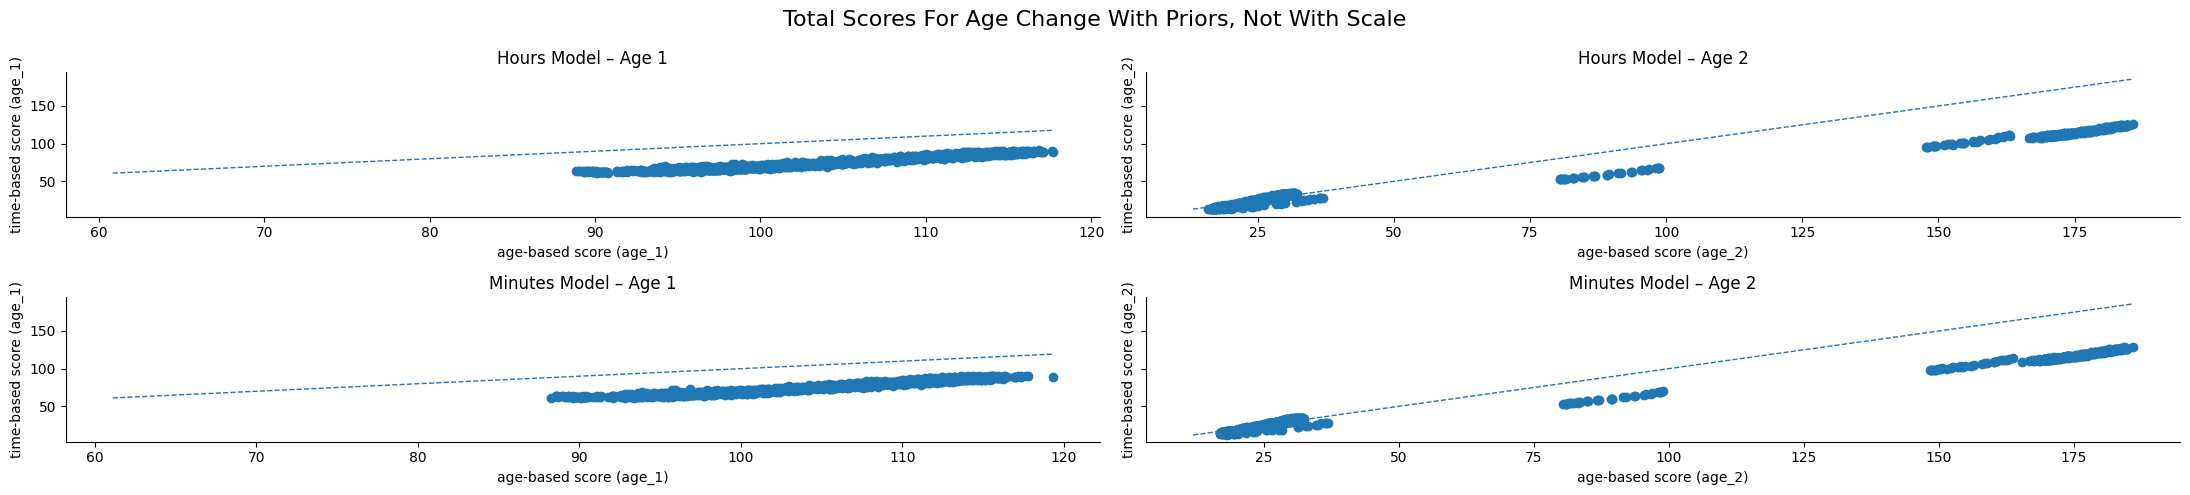

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(22, 5), sharey=True)

axes = axes.flatten()


def add_xy_line(ax, data_x, data_y):
    low = min(data_x.min(), data_y.min())
    high = max(data_x.max(), data_y.max())
    ax.plot([low, high], [low, high], linestyle="--", linewidth=1)


# -------- HOURS DF --------


# subplot 1: age_1 (hours)
x1 = scoring_df_hours["mean_total_scores_hours_age_1_age"]
y1 = scoring_df_hours["mean_total_scores_hours_age_1_hour"]
axes[0].scatter(x1, y1)
add_xy_line(axes[0], x1, y1)
axes[0].set_title("Hours Model – Age 1")
axes[0].set_xlabel("age-based score (age_1)")
axes[0].set_ylabel("time-based score (age_1)")
sns.despine(ax=axes[0])

# subplot 2: age_2 (hours)
x2 = scoring_df_hours["mean_total_scores_hours_age_2_age"]
y2 = scoring_df_hours["mean_total_scores_hours_age_2_hour"]
axes[1].scatter(x2, y2)
add_xy_line(axes[1], x2, y2)
axes[1].set_title("Hours Model – Age 2")
axes[1].set_xlabel("age-based score (age_2)")
axes[1].set_ylabel("time-based score (age_2)")
sns.despine(ax=axes[1])


# -------- MINUTES DF --------

# subplot 3: age_1 (minutes)
x3 = scoring_df_minutes["mean_total_scores_minutes_age_1_age"]
y3 = scoring_df_minutes["mean_total_scores_minutes_age_1_minute"]
axes[2].scatter(x3, y3)
add_xy_line(axes[2], x3, y3)
axes[2].set_title("Minutes Model – Age 1")
axes[2].set_xlabel("age-based score (age_1)")
axes[2].set_ylabel("time-based score (age_1)")
sns.despine(ax=axes[2])

# subplot 4: age_2 (minutes)
x4 = scoring_df_minutes["mean_total_scores_minutes_age_2_age"]
y4 = scoring_df_minutes["mean_total_scores_minutes_age_2_minute"]
axes[3].scatter(x4, y4)
add_xy_line(axes[3], x4, y4)
axes[3].set_title("Minutes Model – Age 2")
axes[3].set_xlabel("age-based score (age_2)")
axes[3].set_ylabel("time-based score (age_2)")
sns.despine(ax=axes[3])

plt.suptitle("Total Scores For Age Change With Priors, Not With Scale", fontsize=16)

plt.tight_layout()
plt.show()

In [27]:
def plot_diff_contour(
    df,
    time_var,  # "hour_norm" or "minute_norm"
    prefix,  # "hours" or "minutes"
    age_label,  # "age_1" or "age_2"
    levels=15,
):
    """
    df: scoring_df_hours or scoring_df_minutes
    time_var: column storing hour_norm or minute_norm
    prefix: "hours" or "minutes"
    age_label: "age_1" or "age_2"
    """

    # Construct correct column names
    col_age_score = f"mean_total_scores_{prefix}_{age_label}_age"
    col_time_score = f"mean_total_scores_{prefix}_{age_label}_{time_var.split('_')[0]}"

    # Extract values
    score_age = df[col_age_score].values
    score_time = df[col_time_score].values

    ages = df["age_norm"].values
    times = df[time_var].values

    # Reshape into mesh
    unique_ages = np.unique(ages)
    unique_times = np.unique(times)

    nA = len(unique_ages)
    nT = len(unique_times)

    A = ages.reshape(nA, nT)
    T = times.reshape(nA, nT)

    Z_age = score_age.reshape(nA, nT)
    Z_time = score_time.reshape(nA, nT)

    Z_diff = Z_age - Z_time

    # ---- PLOT ----
    plt.figure(figsize=(8, 6))
    cmap = "cividis"

    # Use more levels for smoother shading

    # Filled contour
    cont = plt.contourf(A, T, Z_diff, levels=levels, cmap=cmap)

    # Very thin outer contour lines (optional but clearer)
    plt.contour(A, T, Z_diff, levels=levels, colors="black", linewidths=0.25, alpha=0.4)

    plt.xlabel("Age of Applicant")
    plt.ylabel("Time of Application")
    plt.title(
        "Difference: Age Score − Time Of Application Score (Hours, Age_1)",
    )

    plt.colorbar(cont, label="Difference (Age - Time Score)")

    plt.suptitle(
        "Responsibility Of Age Is Always Higher Than That Of Application Time",
        fontsize=16,
    )

    plt.tight_layout()

    fig_path = f"dce/contour_diff_{prefix}_{age_label}.png"
    plt.savefig(fig_path, dpi=300)

    plt.show()


# TODO generalize to minutes too, perhaps

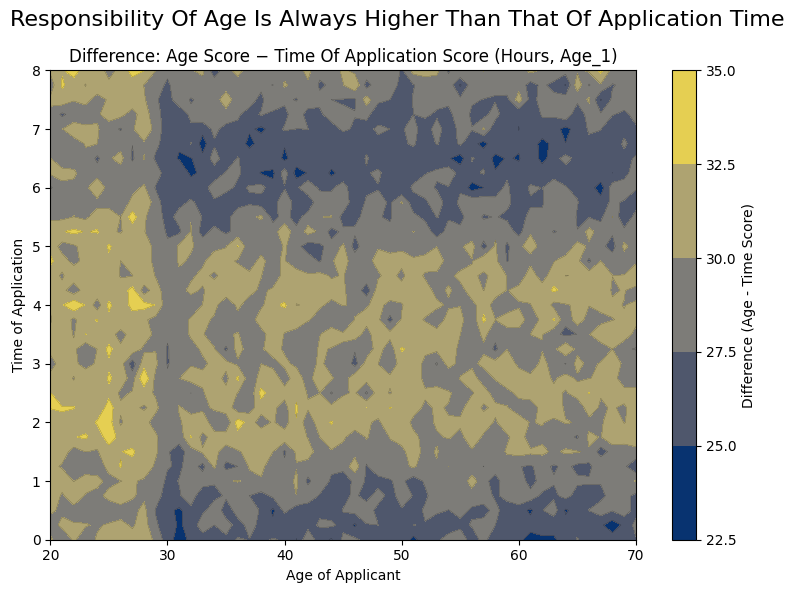

In [28]:
plot_diff_contour(
    scoring_df_hours, time_var="hour_norm", prefix="hours", age_label="age_1", levels=4
)

In [29]:
# (age-40 contour omitted in the simplified figure set: the age-30 contour above is
#  representative, and the other settings give the same qualitative picture. See paper text.)


### Differential causal effect

In [30]:
def add_gradient_scores(df_inputs, model, time_var="hour_norm", grad_prefix="grad"):
    """
    Compute gradients of model output w.r.t age_norm and time_var, and add them to df_inputs.

    Args:
        df_inputs: pd.DataFrame containing 'age_norm' and time_var
        model: callable model(age_tensor, time_tensor)
        time_var: str, either 'hour_norm' or 'minute_norm'
        grad_prefix: prefix for new gradient columns

    Returns:
        pd.DataFrame with gradient columns appended
    """
    age_grad = torch.tensor(
        df_inputs["age_norm"].values, dtype=torch.float32, requires_grad=True
    )
    time_grad = torch.tensor(
        df_inputs[time_var].values, dtype=torch.float32, requires_grad=True
    )

    grads_age = []
    grads_time = []

    N = len(df_inputs)

    for i in range(N):
        age_i = age_grad[i : i + 1]
        time_i = time_grad[i : i + 1]

        out = model(age_i, time_i)

        grad_age, grad_time = torch.autograd.grad(
            outputs=out, inputs=(age_grad, time_grad), retain_graph=True
        )

        grads_age.append(grad_age[i])
        grads_time.append(grad_time[i])

    # Stack and convert to numpy
    grads_age = torch.stack(grads_age).numpy()
    grads_time = torch.stack(grads_time).numpy()

    # Append to DataFrame
    df_inputs[f"{grad_prefix}_age_norm"] = grads_age
    df_inputs[f"{grad_prefix}_{time_var}"] = grads_time

    return df_inputs

In [31]:
# Hours model
scoring_df_hours = add_gradient_scores(
    scoring_df_hours,
    internal_model_hours,
    time_var="hour_norm",
    grad_prefix="grad_hours",
)

# Minutes model
scoring_df_minutes = add_gradient_scores(
    scoring_df_minutes,
    internal_model_minutes,
    time_var="minute_norm",
    grad_prefix="grad_minutes",
)

In [32]:
display(scoring_df_minutes.head())

,age_norm,minute_norm,mean_total_scores_minutes_age_1_age,mean_total_scores_minutes_age_1_minute,mean_total_scores_minutes_age_2_age,mean_total_scores_minutes_age_2_minute,grad_minutes_age_norm,grad_minutes_minute_norm
0,20.0,0.0,95.850647,64.947624,171.312485,112.795670,8.491953e-07,-6.338002e-09
1,20.0,15.0,95.088326,66.667442,169.926147,111.865868,8.484766e-07,-3.469996e-02
2,20.0,30.0,97.548485,68.142998,170.527649,113.504463,8.463622e-07,-6.738329e-02
3,20.0,45.0,95.933380,63.564137,172.359634,113.323616,8.429751e-07,-9.615052e-02
4,20.0,60.0,96.415512,63.972469,172.443634,114.362335,8.385119e-07,-1.193299e-01


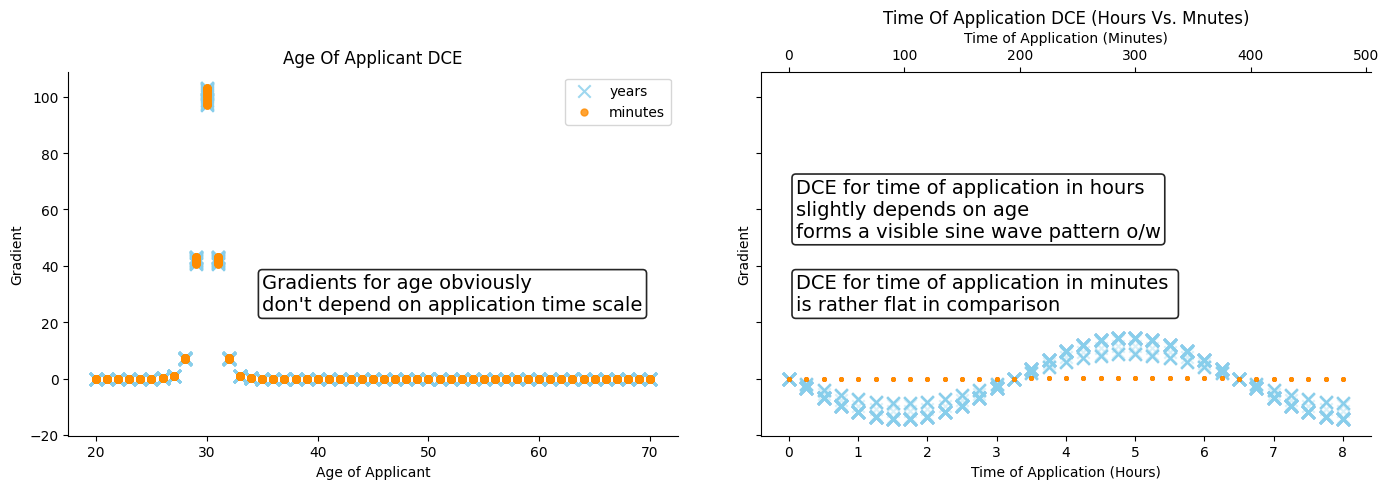

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


df = scoring_df_hours
age_col = "age_norm"
time_col = "hour_norm"
age_grad_col = "grad_hours_age_norm"
time_grad_col = "grad_hours_hour_norm"


axes[0].scatter(
    df[age_col],
    df[age_grad_col],
    alpha=0.8,
    s=80,
    label="years",
    marker="x",
    color="skyblue",
)
axes[0].set_xlabel("Age of Applicant")
axes[0].set_ylabel("Gradient")
axes[0].set_title("Age Of Appplicant (DCE)")
axes[0].legend()


axes[1].scatter(
    df[time_col],
    df[time_grad_col],
    alpha=0.3,
    s=80,
    label="years",
    marker="x",
    color="skyblue",
)
axes[1].set_xlabel("Time of Application (Hours)")
axes[1].set_ylabel("Gradient")
axes[1].set_title("Time Of Application DCE (Hours Vs. Mnutes)")

add_line_end_label(
    axes[1],
    0.1,
    60,
    "DCE for time of application in hours \nslightly depends on age \nforms a visible sine wave pattern o/w",
)

add_line_end_label(
    axes[1],
    0.1,
    30,
    "DCE for time of application in minutes \nis rather flat in comparison",
)


df = scoring_df_minutes
age_col = "age_norm"
time_col = "minute_norm"
age_grad_col = "grad_minutes_age_norm"
time_grad_col = "grad_minutes_minute_norm"

axes[0].scatter(
    df[age_col], df[age_grad_col], alpha=0.8, s=25, label="minutes", color="darkorange"
)
axes[0].set_ylabel("Gradient")
axes[0].set_title("Age Of Applicant DCE")
axes[0].legend()

add_line_end_label(
    axes[0],
    35,
    30,
    "Gradients for age obviously \ndon't depend on application time scale",
)


ax_minutes = axes[1].secondary_xaxis(
    "top",
    functions=(
        lambda h: h * 60,  # convert hours → minutes for tick display
        lambda m: m / 60,  # convert minutes → hours to map coords
    ),
)

ax_minutes.set_xlabel("Time of Application (Minutes)")


axes[1].scatter(
    df[time_col] / 60,
    df[time_grad_col],
    alpha=0.3,
    s=5,
    label="minutes",
    color="darkorange",
)

sns.despine()
plt.tight_layout()
file_path = "dce/dce_age_time_hours_minutes.png"
plt.savefig(file_path, dpi=300)
plt.show()